# GenKI Workflow

## Mouse Paul15 Single-cell RNA-seq

### Objective

Prepare a mouse single-cell RNA-seq dataset for downstream GenKI virtual gene knockout analysis.

### Dataset

- Species: Mouse
- Dataset: Paul15
- Format: AnnData (.h5ad)
- Input file: `data/mouse_paul15.h5ad`

In [7]:
# Step 1. Import libraries

import os

import scanpy as sc
import pandas as pd
import numpy as np

In [8]:
# Step 2. Configure Scanpy

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")

print("Scanpy version:", sc.__version__)

Scanpy version: 1.11.5


/tmp/ipykernel_151/3377041067.py:6: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [44]:
# Step 3. Load the dataset

adata = sc.read_h5ad("../sample_data/raw_example/mouse_paul15.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 700 × 3451
    obs: 'paul15_clusters', 'cell_type'
    uns: 'iroot'


In [10]:
# Step 4. Inspect cell metadata

adata.obs.head()

,paul15_clusters,cell_type
W31109,3Ery,3Ery
W31118,14Mo,14Mo
W31121,7MEP,7MEP
W31126,3Ery,3Ery
W31127,9GMP,9GMP


In [11]:
# Step 5. Inspect gene metadata

adata.var.head()

""
0610007L01Rik
0610009O20Rik
0610010K14Rik
0910001L09Rik
1100001G20Rik


In [12]:
# Step 6. Explore the expression matrix

print(type(adata.X))
print(adata.X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(700, 3451)


In [13]:
# Step 7. Preview the expression matrix

adata.X[:5, :5].toarray()

array([[0., 3., 8., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.]], dtype=float32)

In [14]:
# Step 8. Dataset summary

print(f"Number of cells : {adata.n_obs}")
print(f"Number of genes : {adata.n_vars}")
print(f"Shape           : {adata.shape}")
print(f"Matrix type     : {type(adata.X)}")

Number of cells : 700
Number of genes : 3451
Shape           : (700, 3451)
Matrix type     : <class 'scipy.sparse._csr.csr_matrix'>


In [15]:
# Step 9. Count cell types

cell_counts = adata.obs["cell_type"].value_counts()

print(cell_counts)

cell_type
14Mo       92
13Baso     83
2Ery       79
3Ery       71
15Mo       47
6Ery       45
5Ery       44
10GMP      43
7MEP       39
16Neu      39
4Ery       34
8Mk        19
1Ery       15
12Baso     15
9GMP       15
11DC        7
19Lymph     7
17Neu       5
18Eos       1
Name: count, dtype: int64


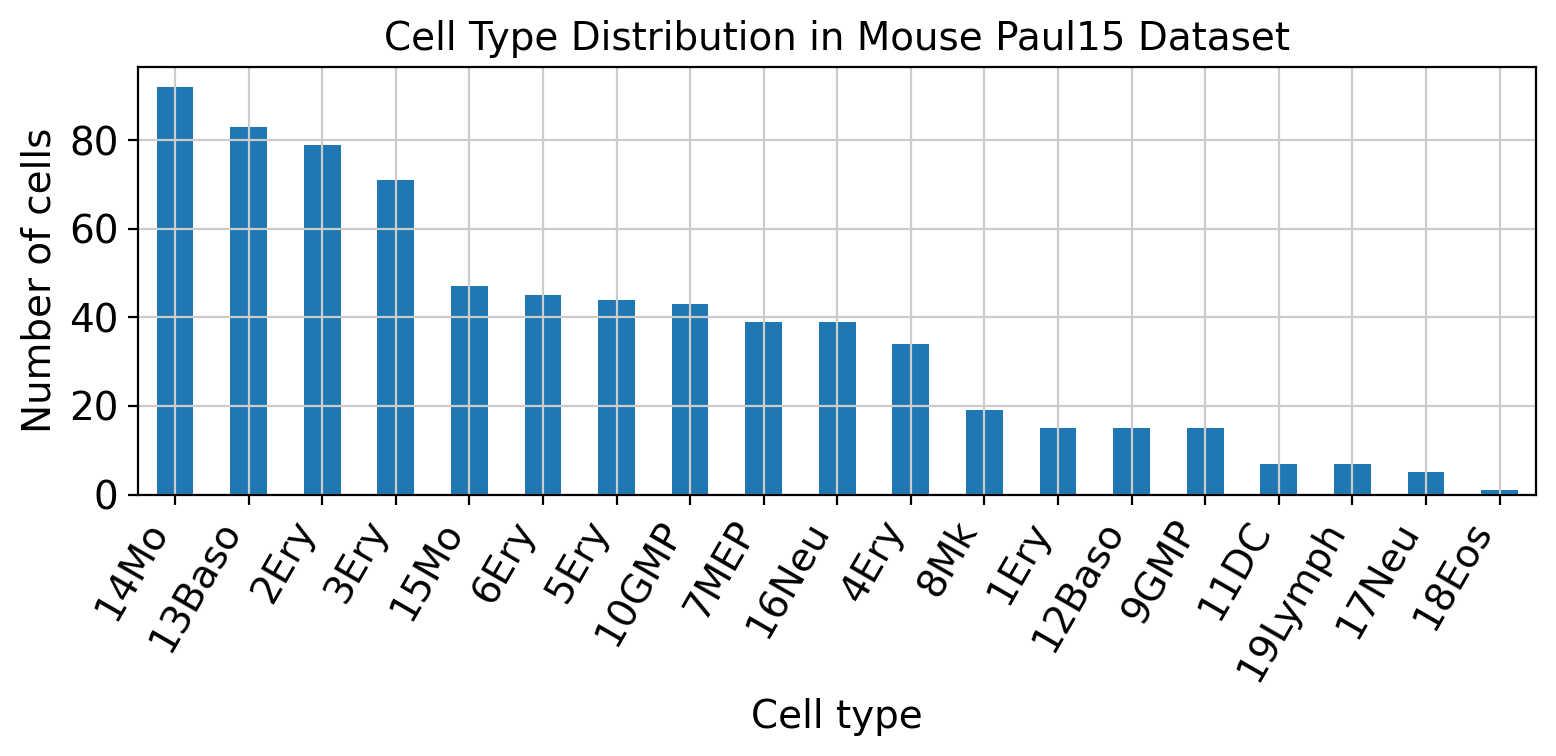

In [16]:
# Step 10. Plot cell type distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
cell_counts.plot(kind="bar")

plt.title("Cell Type Distribution in Mouse Paul15 Dataset")
plt.xlabel("Cell type")
plt.ylabel("Number of cells")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

plt.show()

In [22]:
# Step 11. Save figure to Docker project folder

import os

save_dir = "../student_inputs/genki"
os.makedirs(save_dir, exist_ok=True)

figure_path = os.path.join(save_dir, "figure01_cell_type_distribution.png")

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Figure saved to: {figure_path}")

Figure saved to: ../student_inputs/genki/figure01_cell_type_distribution.png


<Figure size 400x400 with 0 Axes>

In [23]:
# Step 12. Check available metadata fields

print("obs columns:")
print(adata.obs.columns)

print("\nvar columns:")
print(adata.var.columns)

print("\nuns keys:")
print(adata.uns.keys())

obs columns:
Index(['paul15_clusters', 'cell_type'], dtype='object')

var columns:
Index([], dtype='object')

uns keys:
dict_keys(['iroot'])


In [24]:
# Step 13. Check matrix sparsity

import numpy as np

total_values = adata.X.shape[0] * adata.X.shape[1]
nonzero_values = adata.X.count_nonzero()
zero_values = total_values - nonzero_values

print(f"Total values: {total_values:,}")
print(f"Non-zero values: {nonzero_values:,}")
print(f"Zero values: {zero_values:,}")
print(f"Sparsity: {zero_values / total_values:.2%}")

Total values: 2,415,700
Non-zero values: 614,820
Zero values: 1,800,880
Sparsity: 74.55%


In [25]:
# Step 14. Explore expression of the first gene

gene_name = adata.var_names[0]

print("First gene:", gene_name)

expression = adata[:, gene_name].X.toarray().flatten()

print("First 20 expression values:")
print(expression[:20])

First gene: 0610007L01Rik
First 20 expression values:
[0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 2. 0. 2. 0. 0. 0. 0. 0. 0. 1.]


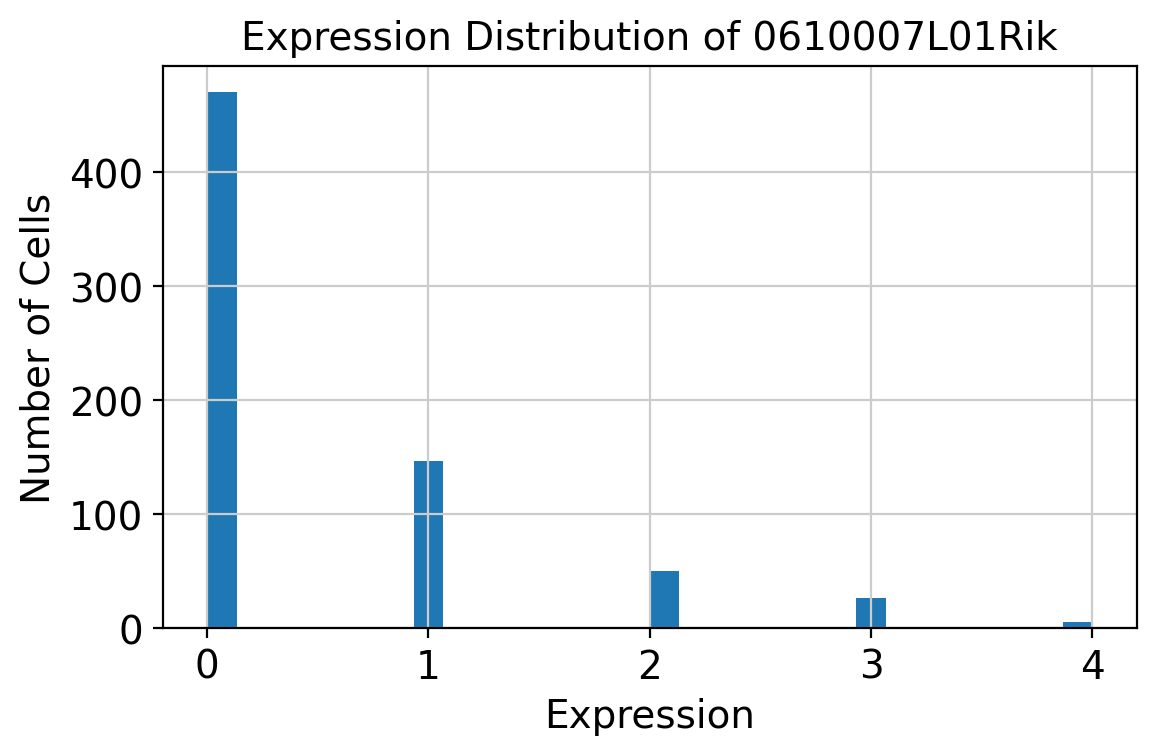

Figure saved to: ../student_inputs/genki/figure02_gene_expression_histogram.png


In [26]:
# Step 15. Plot gene expression histogram

import matplotlib.pyplot as plt
import os

# Expression of the first gene
gene_name = adata.var_names[0]
expression = adata[:, gene_name].X.toarray().flatten()

# Plot
plt.figure(figsize=(6,4))
plt.hist(expression, bins=30)

plt.title(f"Expression Distribution of {gene_name}")
plt.xlabel("Expression")
plt.ylabel("Number of Cells")

plt.tight_layout()

# Save figure
save_dir = "../student_inputs/genki"
os.makedirs(save_dir, exist_ok=True)

figure_path = os.path.join(
    save_dir,
    "figure02_gene_expression_histogram.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [27]:
# Step 16. Summary statistics of one gene

import numpy as np

gene_name = adata.var_names[0]
expression = adata[:, gene_name].X.toarray().flatten()

print(f"Gene: {gene_name}")
print(f"Mean expression: {np.mean(expression):.3f}")
print(f"Median expression: {np.median(expression):.3f}")
print(f"Maximum expression: {np.max(expression)}")
print(f"Minimum expression: {np.min(expression)}")
print(f"Standard deviation: {np.std(expression):.3f}")
print(f"Cells expressing this gene: {(expression > 0).sum()} / {len(expression)}")

Gene: 0610007L01Rik
Mean expression: 0.503
Median expression: 0.000
Maximum expression: 4.0
Minimum expression: 0.0
Standard deviation: 0.853
Cells expressing this gene: 230 / 700


/tmp/ipykernel_151/1590310108.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cell_type")["expression"]


cell_type
16Neu      1.076923
18Eos      1.000000
2Ery       0.772152
3Ery       0.732394
15Mo       0.723404
14Mo       0.619565
4Ery       0.470588
13Baso     0.421687
5Ery       0.409091
1Ery       0.333333
6Ery       0.288889
8Mk        0.263158
10GMP      0.209302
19Lymph    0.142857
12Baso     0.066667
9GMP       0.066667
7MEP       0.025641
11DC       0.000000
17Neu      0.000000
Name: expression, dtype: float32


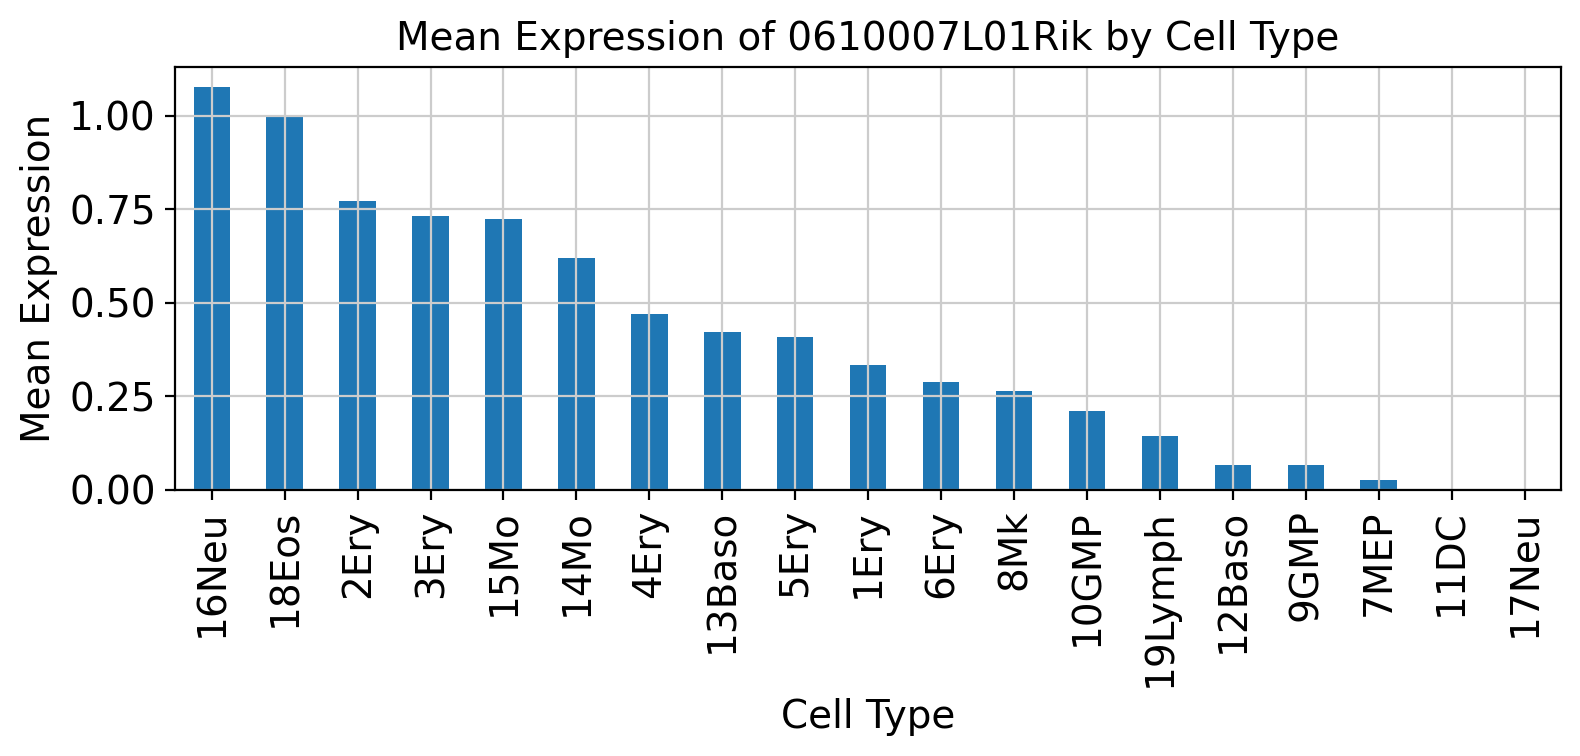

Figure saved to: ../student_inputs/genki/figure03_mean_expression_by_celltype.png


In [28]:
# Step 17. Mean gene expression by cell type

import pandas as pd
import matplotlib.pyplot as plt
import os

gene_name = adata.var_names[0]
expression = adata[:, gene_name].X.toarray().flatten()

# Create a dataframe
df = pd.DataFrame({
    "cell_type": adata.obs["cell_type"],
    "expression": expression
})

# Calculate mean expression
mean_expression = (
    df.groupby("cell_type")["expression"]
      .mean()
      .sort_values(ascending=False)
)

print(mean_expression)

# Plot
plt.figure(figsize=(8,4))
mean_expression.plot(kind="bar")

plt.title(f"Mean Expression of {gene_name} by Cell Type")
plt.xlabel("Cell Type")
plt.ylabel("Mean Expression")

plt.tight_layout()

# Save figure
save_dir = "../student_inputs/genki"
os.makedirs(save_dir, exist_ok=True)

figure_path = os.path.join(
    save_dir,
    "figure03_mean_expression_by_celltype.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [29]:
# Step 18. Calculate total counts per cell

# Total expression count for each cell
adata.obs["total_counts"] = np.array(adata.X.sum(axis=1)).flatten()

print(adata.obs[["cell_type", "total_counts"]].head())

print("\nSummary of total counts:")
print(adata.obs["total_counts"].describe())

       cell_type  total_counts
W31109      3Ery        5205.0
W31118      14Mo        1965.0
W31121      7MEP         285.0
W31126      3Ery        2153.0
W31127      9GMP        1540.0

Summary of total counts:
count      700.000000
mean      2226.717041
std       1470.800415
min        285.000000
25%       1148.750000
50%       1987.000000
75%       3031.750000
max      11712.000000
Name: total_counts, dtype: float64


In [30]:
# Step 19. Find the most highly expressed genes

import pandas as pd

# Mean expression of each gene
gene_mean = np.array(adata.X.mean(axis=0)).flatten()

gene_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Mean_expression": gene_mean
})

gene_table = gene_table.sort_values(
    by="Mean_expression",
    ascending=False
)

print(gene_table.head(20))

          Gene  Mean_expression
196       Actb        26.030037
1913       Mpo        25.365774
2628      Rpl4        24.987194
1320    Gnb2l1        21.602911
1496  Hsp90ab1        21.230043
2640      Rps3        20.934351
2425     Prtn3        17.825741
1351      Gpx1        15.138580
1298   Gm10653        14.345737
2025       Ncl        13.910032
553       Car2        13.604293
144   AK158095        13.418584
998       Eef2        12.894312
534       Calr        12.480025
2622    Rpl13a        11.954316
1040     Elane        11.920012
552       Car1        11.438586
393      Atp5b         9.487161
815       Ctsg         8.975724
2636     Rps20         8.774303


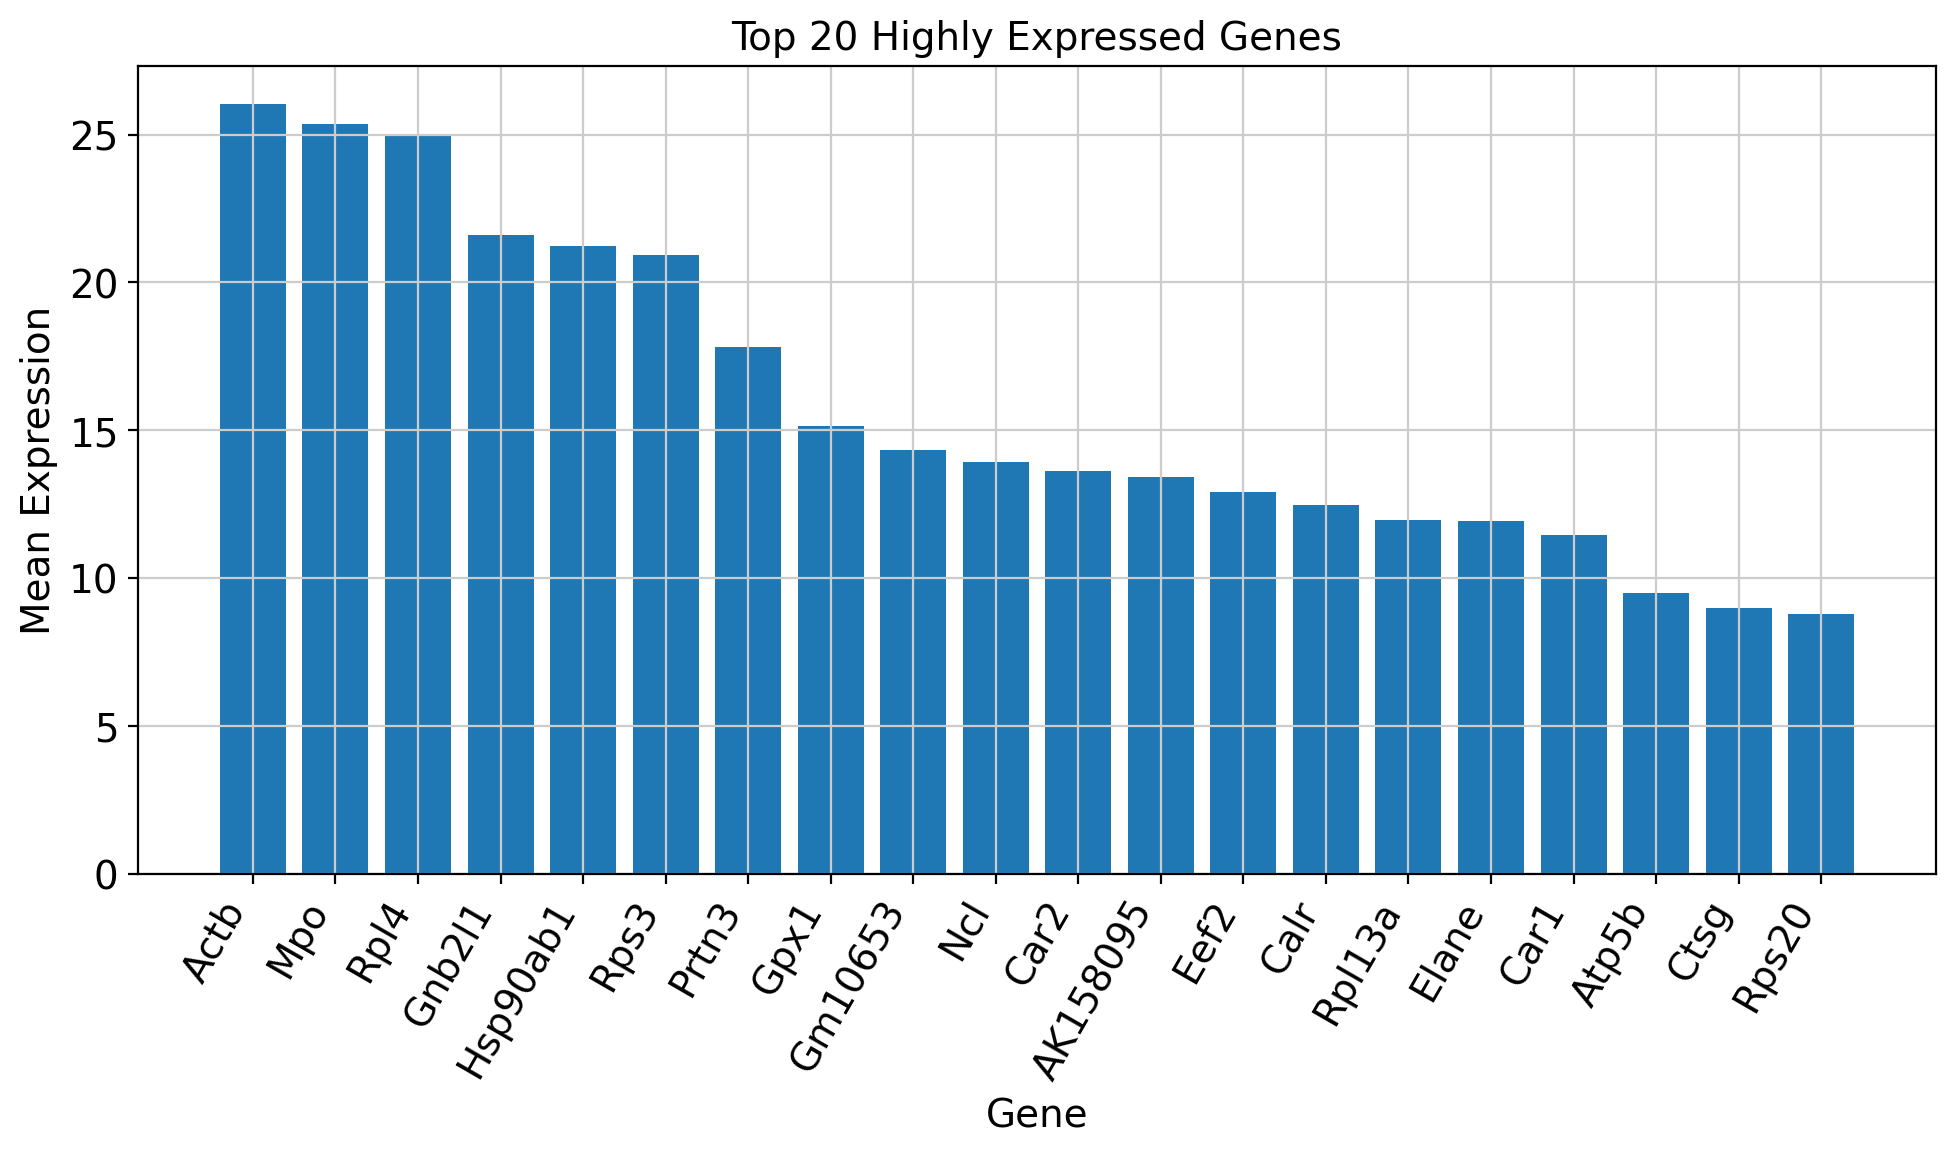

Figure saved to: ../student_inputs/genki/figure04_top20_genes.png


In [31]:
# Step 20. Plot top 20 highly expressed genes

import matplotlib.pyplot as plt

top20 = gene_table.head(20)

plt.figure(figsize=(10, 6))
plt.bar(top20["Gene"], top20["Mean_expression"])

plt.title("Top 20 Highly Expressed Genes")
plt.xlabel("Gene")
plt.ylabel("Mean Expression")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

# Save figure
figure_path = "../student_inputs/genki/figure04_top20_genes.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [32]:
# Step 21. Find the most variable genes

import pandas as pd
import numpy as np

# Variance of each gene
gene_variance = np.array(adata.X.toarray().var(axis=0))

variance_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Variance": gene_variance
})

variance_table = variance_table.sort_values(
    by="Variance",
    ascending=False
)

print(variance_table.head(20))

          Gene     Variance
1913       Mpo  1020.065979
2425     Prtn3   687.544189
1040     Elane   470.603790
553       Car2   392.536560
552       Car1   304.061310
2628      Rpl4   296.106812
196       Actb   286.023315
1496  Hsp90ab1   236.862839
1320    Gnb2l1   210.773956
815       Ctsg   174.760742
534       Calr   164.461090
2640      Rps3   159.007202
2025       Ncl   151.830811
1298   Gm10653   128.023483
144   AK158095   108.277725
998       Eef2    99.825851
1351      Gpx1    94.739349
2622    Rpl13a    76.629433
1212      Fth1    63.906673
393      Atp5b    63.084164


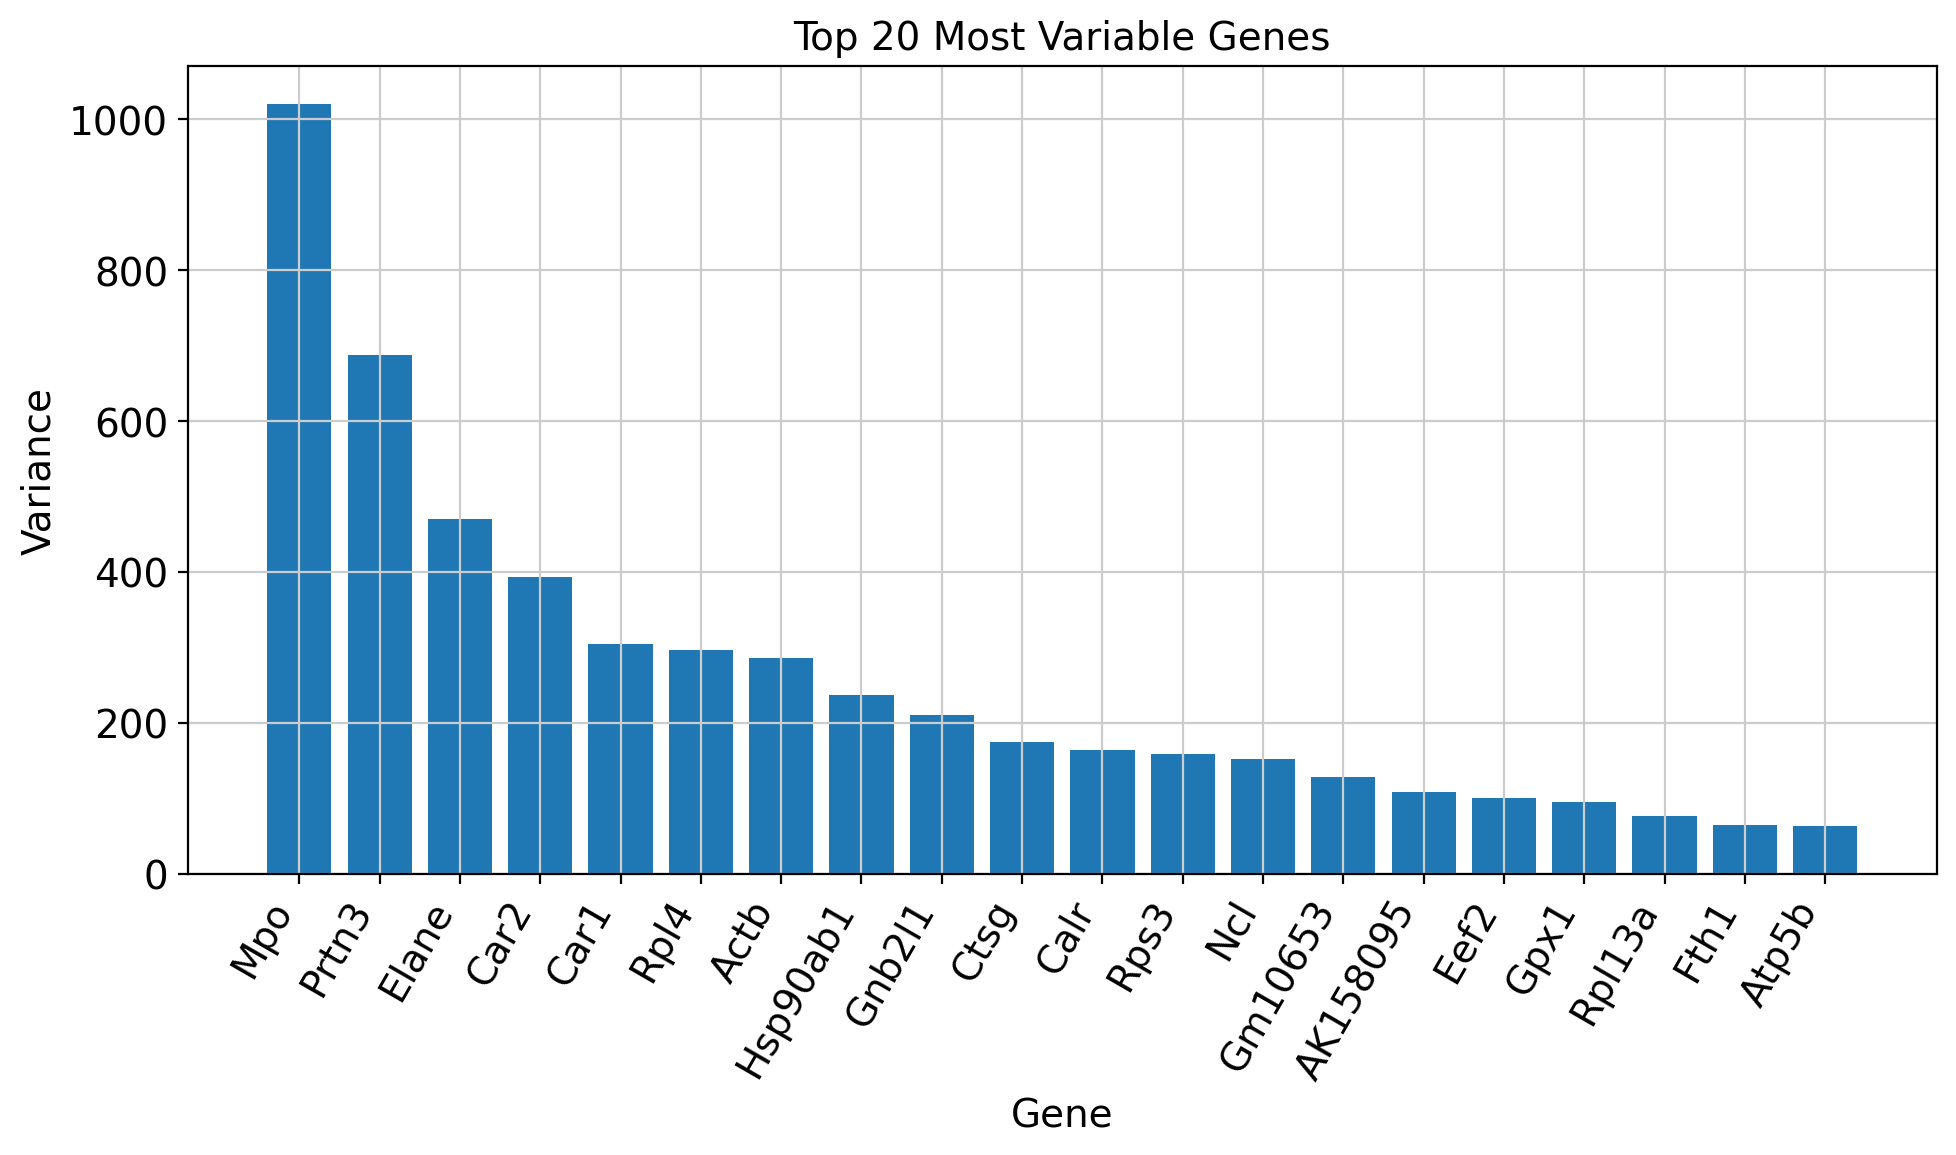

Figure saved to: ../student_inputs/genki/figure05_top20_variable_genes.png


In [33]:
# Step 22. Plot the Top 20 Most Variable Genes

import matplotlib.pyplot as plt

top20_var = variance_table.head(20)

plt.figure(figsize=(10,6))

plt.bar(top20_var["Gene"], top20_var["Variance"])

plt.title("Top 20 Most Variable Genes")
plt.xlabel("Gene")
plt.ylabel("Variance")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()

# Save figure
figure_path = "../student_inputs/genki/figure05_top20_variable_genes.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [34]:
# Step 23. Genes expressed in the largest number of cells

import pandas as pd
import numpy as np

# Number of cells expressing each gene
cells_expressing = np.array((adata.X > 0).sum(axis=0)).flatten()

expressed_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Cells_expressing": cells_expressing
})

expressed_table = expressed_table.sort_values(
    by="Cells_expressing",
    ascending=False
)

print(expressed_table.head(20))

          Gene  Cells_expressing
1320    Gnb2l1               700
196       Actb               699
2640      Rps3               699
2628      Rpl4               697
1496  Hsp90ab1               695
998       Eef2               693
2622    Rpl13a               691
1351      Gpx1               690
1298   Gm10653               689
2636     Rps20               686
144   AK158095               683
2025       Ncl               677
1913       Mpo               672
3250       Ubb               670
2629     Rplp2               670
393      Atp5b               667
1213      Ftl1               665
683       Cfl1               665
2621     Rpl13               662
2645      Rps8               661


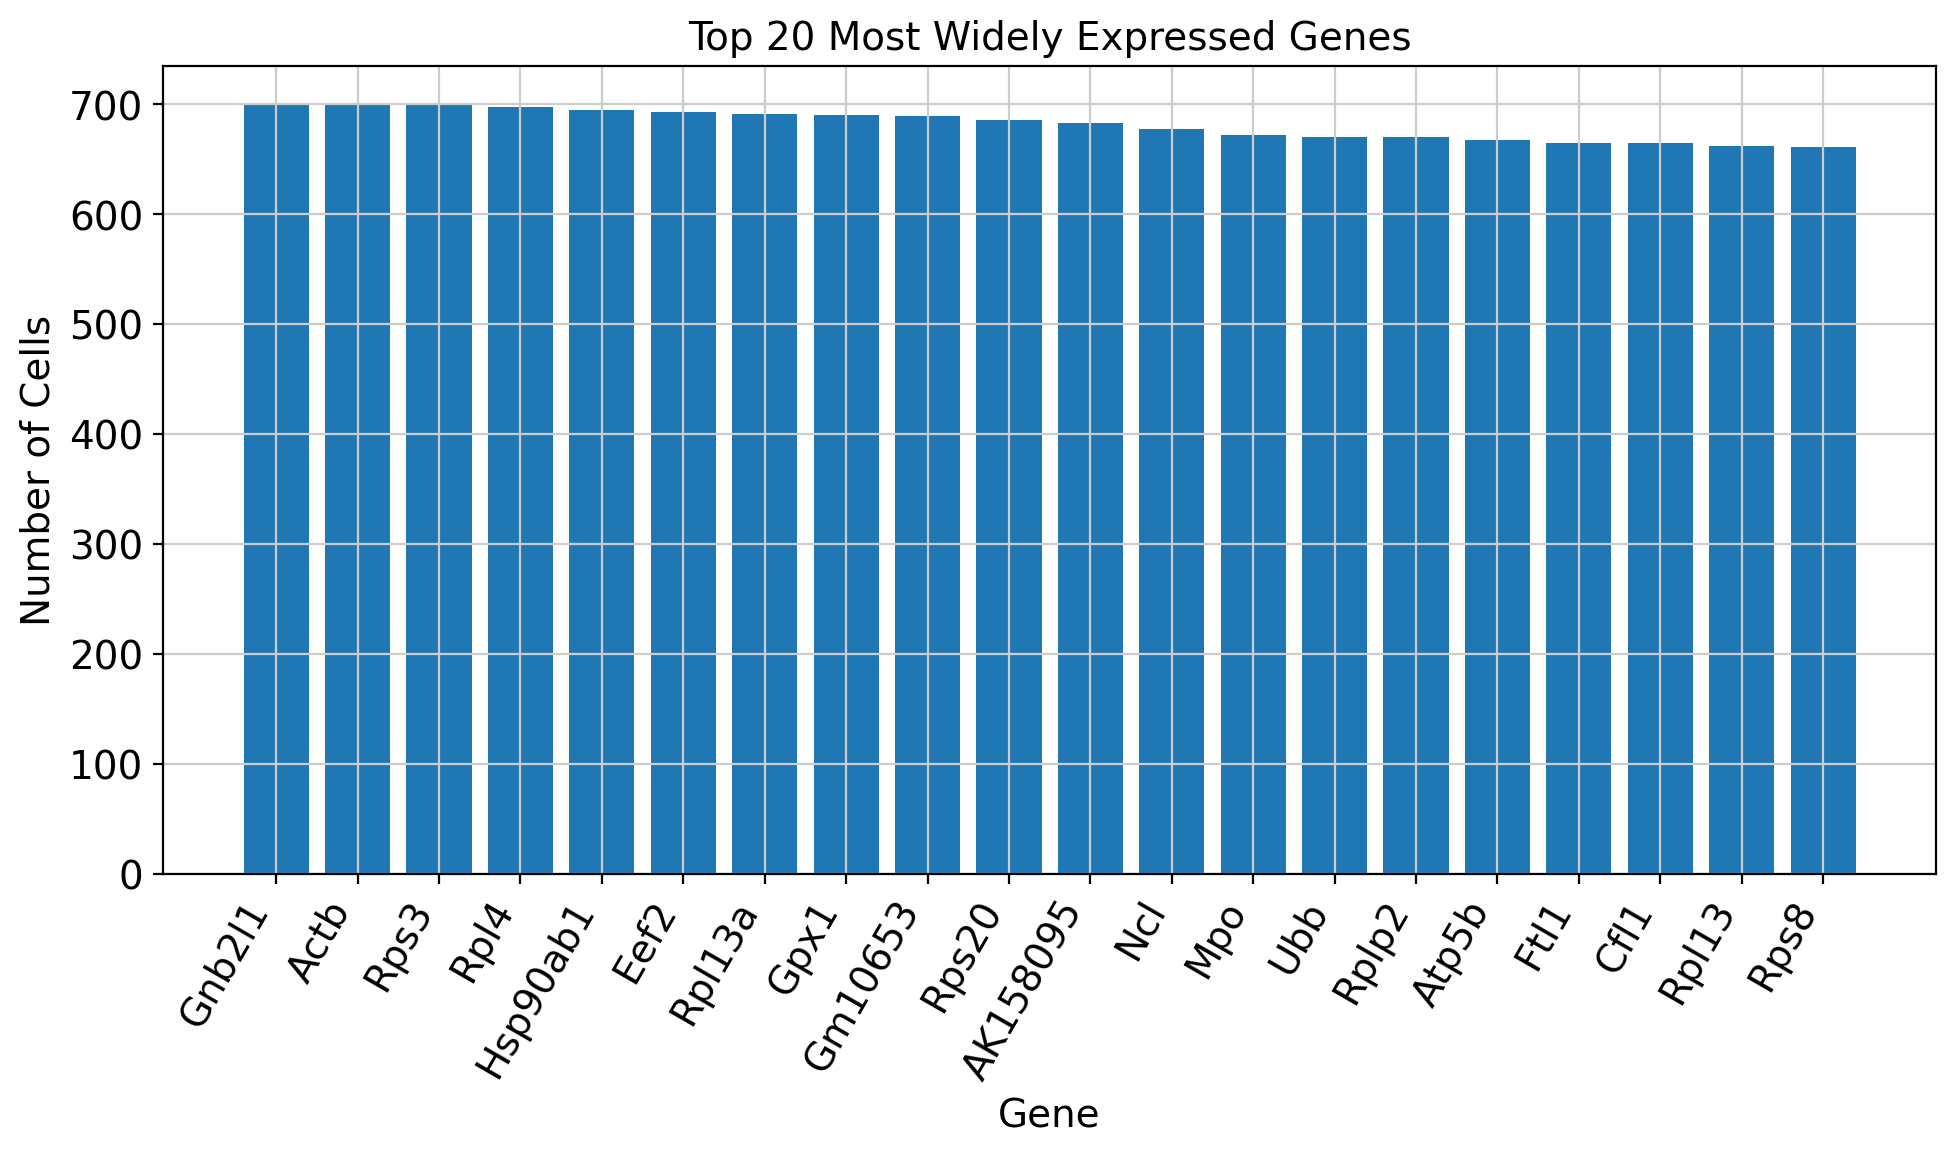

Figure saved to: ../student_inputs/genki/figure06_top20_cells_expressing_genes.png


In [35]:
# Step 24. Plot the Top 20 Most Widely Expressed Genes

import matplotlib.pyplot as plt

top20_expressed = expressed_table.head(20)

plt.figure(figsize=(10,6))

plt.bar(
    top20_expressed["Gene"],
    top20_expressed["Cells_expressing"]
)

plt.title("Top 20 Most Widely Expressed Genes")
plt.xlabel("Gene")
plt.ylabel("Number of Cells")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()

# Save figure
figure_path = "../student_inputs/genki/figure06_top20_cells_expressing_genes.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [37]:
# Step 21. Calculate percentage of cells expressing each gene

import numpy as np
import pandas as pd

cells_expressing_percent = (
    (adata.X > 0).sum(axis=0)
    / adata.n_obs
    * 100
)

cells_expressing_percent = np.asarray(cells_expressing_percent).flatten()

percent_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Percent_cells": cells_expressing_percent
})

percent_table = percent_table.sort_values(
    by="Percent_cells",
    ascending=False
)

print(percent_table.head(20))

          Gene  Percent_cells
1320    Gnb2l1     100.000000
196       Actb      99.857143
2640      Rps3      99.857143
2628      Rpl4      99.571429
1496  Hsp90ab1      99.285714
998       Eef2      99.000000
2622    Rpl13a      98.714286
1351      Gpx1      98.571429
1298   Gm10653      98.428571
2636     Rps20      98.000000
144   AK158095      97.571429
2025       Ncl      96.714286
1913       Mpo      96.000000
3250       Ubb      95.714286
2629     Rplp2      95.714286
393      Atp5b      95.285714
1213      Ftl1      95.000000
683       Cfl1      95.000000
2621     Rpl13      94.571429
2645      Rps8      94.428571


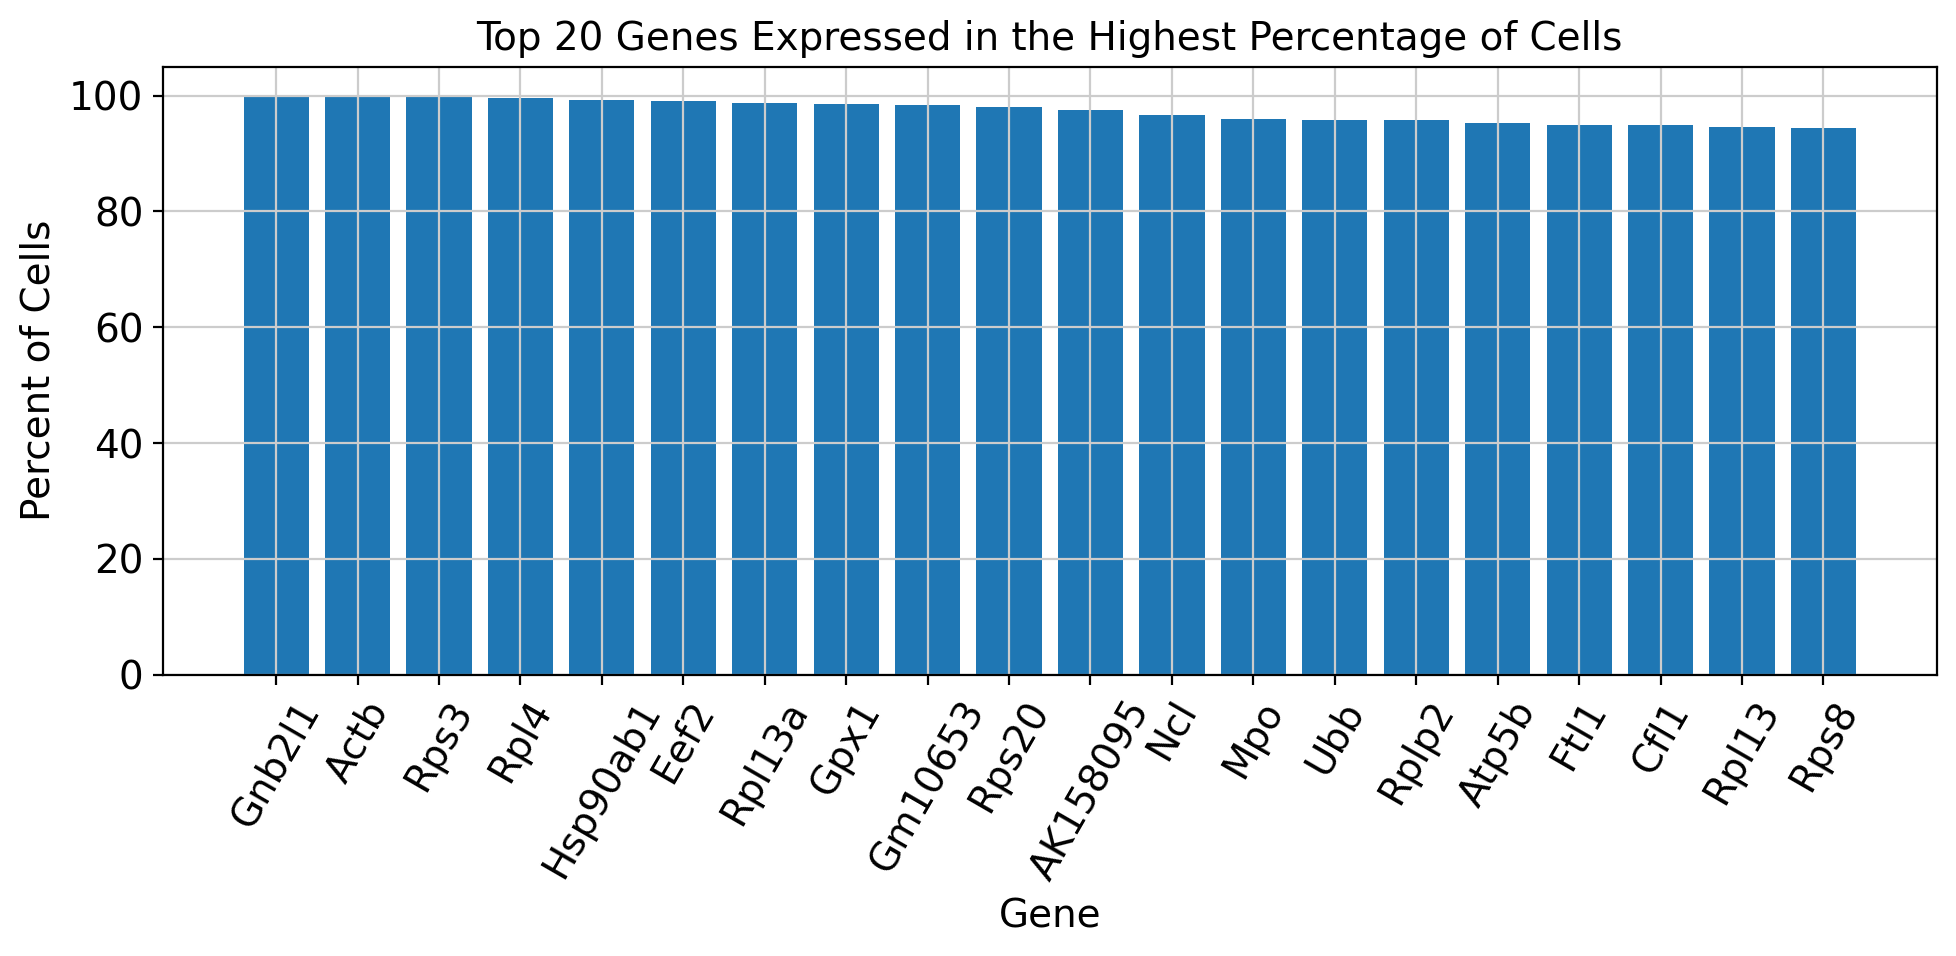

Figure saved to: ../student_inputs/genki/figure07_top20_percent_cells.png


In [38]:
# Step 22. Plot genes expressed in the highest percentage of cells

import matplotlib.pyplot as plt
import os

top20 = percent_table.head(20)

plt.figure(figsize=(10,5))
plt.bar(top20["Gene"], top20["Percent_cells"])

plt.xticks(rotation=60)
plt.xlabel("Gene")
plt.ylabel("Percent of Cells")
plt.title("Top 20 Genes Expressed in the Highest Percentage of Cells")

plt.tight_layout()

# Save figure
figure_path = os.path.join(
    save_dir,
    "figure07_top20_percent_cells.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [39]:
# Step 23. Find genes expressed in the fewest cells

cells_expressing = np.asarray((adata.X > 0).sum(axis=0)).flatten()

low_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Cells_expressing": cells_expressing
})

low_table = low_table.sort_values(
    by="Cells_expressing",
    ascending=True
)

print(low_table.head(20))

          Gene  Cells_expressing
3168     Tpsb2                 0
2670    S100a9                 1
739       Cmah                 1
385     Atp1b1                 1
742      Cmtm4                 1
1344     Gpr18                 1
1841     Mcpt4                 1
338   Arhgef40                 1
570       Cbr3                 1
698     Chi3l3                 2
584     Ccdc48                 2
3061      Thy1                 2
1259      Gbx2                 2
1946     Mrvi1                 2
738       Cma1                 2
1947    Ms4a4b                 2
1613     Itm2a                 2
2115      Nrp2                 2
411     Atp8b5                 2
862       Darc                 2


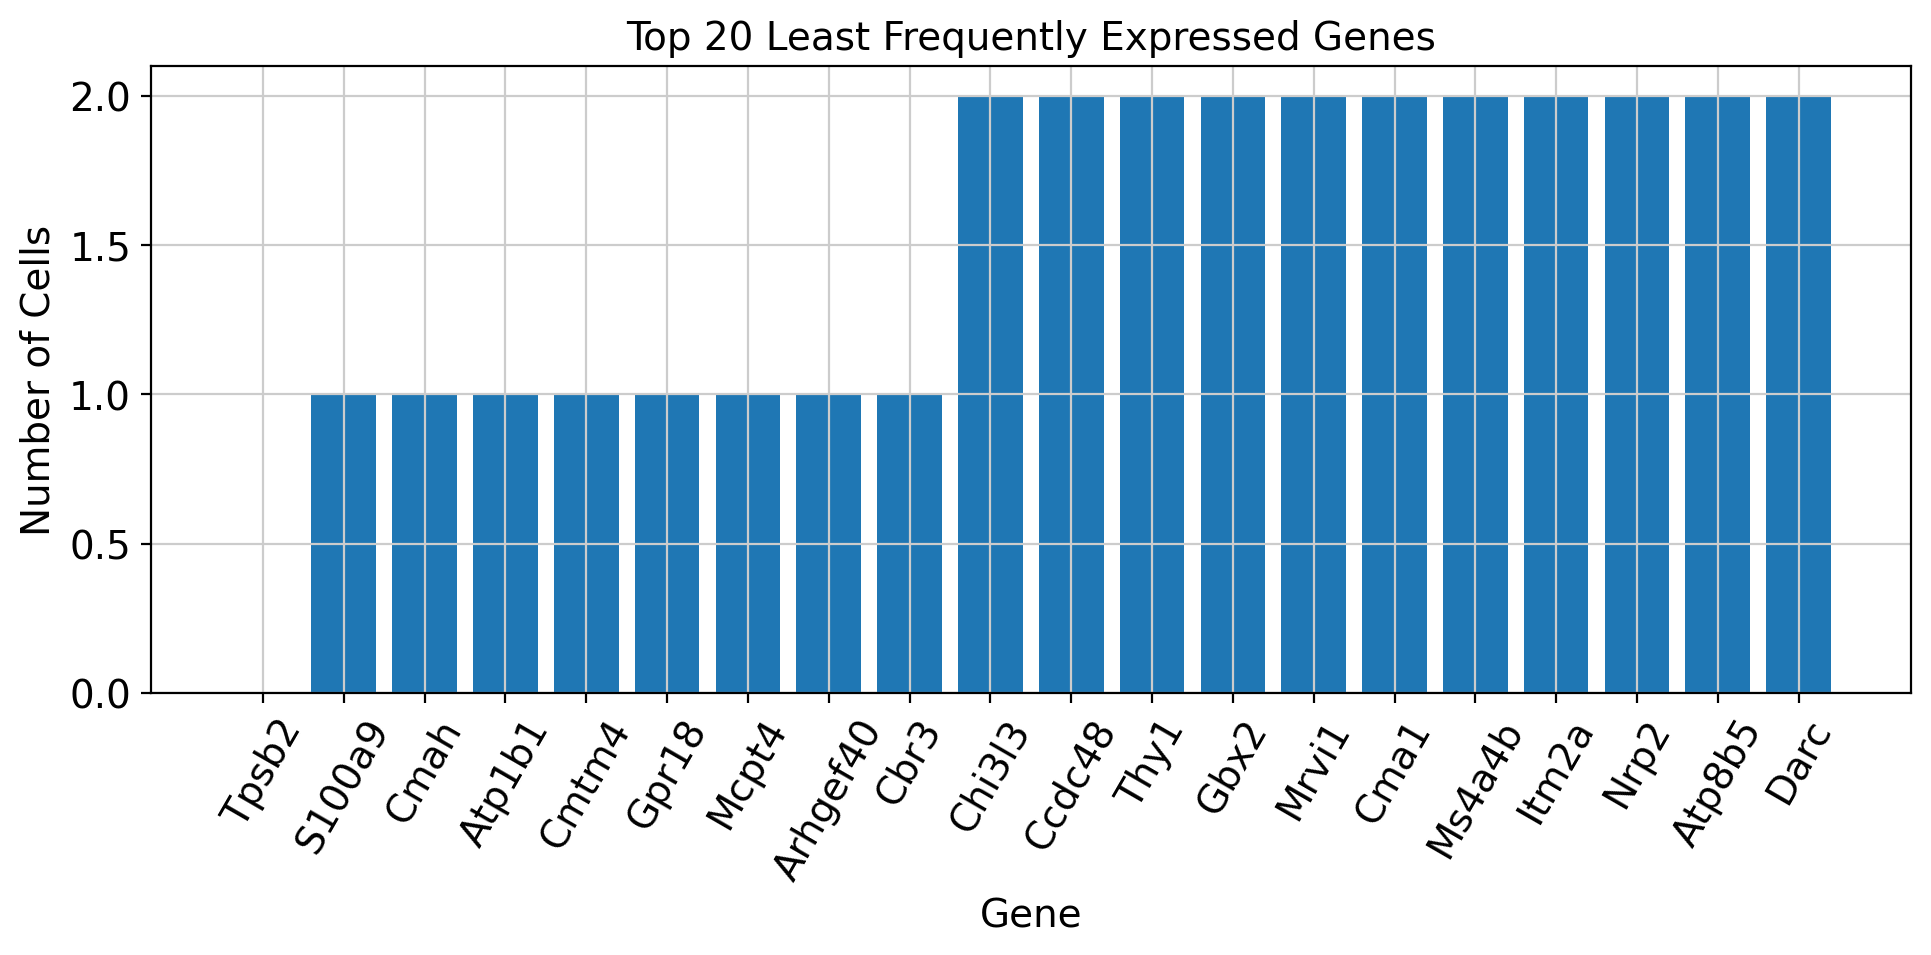

Figure saved to: ../student_inputs/genki/figure08_bottom20_cells_expressing.png


In [40]:
# Step 24. Plot genes expressed in the fewest cells

import matplotlib.pyplot as plt
import os

bottom20 = low_table.head(20)

plt.figure(figsize=(10,5))
plt.bar(bottom20["Gene"], bottom20["Cells_expressing"])

plt.xticks(rotation=60)
plt.xlabel("Gene")
plt.ylabel("Number of Cells")
plt.title("Top 20 Least Frequently Expressed Genes")

plt.tight_layout()

figure_path = os.path.join(
    save_dir,
    "figure08_bottom20_cells_expressing.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [41]:
# Step 25. Calculate sparsity of each gene

import numpy as np
import pandas as pd

gene_zero_percent = (
    (adata.X == 0).sum(axis=0)
    / adata.n_obs
    * 100
)

gene_zero_percent = np.asarray(gene_zero_percent).flatten()

zero_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Zero_percent": gene_zero_percent
})

zero_table = zero_table.sort_values(
    by="Zero_percent",
    ascending=False
)

print(zero_table.head(20))

          Gene  Zero_percent
3168     Tpsb2    100.000000
739       Cmah     99.857143
742      Cmtm4     99.857143
570       Cbr3     99.857143
1344     Gpr18     99.857143
1841     Mcpt4     99.857143
385     Atp1b1     99.857143
2670    S100a9     99.857143
338   Arhgef40     99.857143
411     Atp8b5     99.714286
2656      Rtkn     99.714286
698     Chi3l3     99.714286
1389      Gzmb     99.714286
1613     Itm2a     99.714286
3061      Thy1     99.714286
1946     Mrvi1     99.714286
2115      Nrp2     99.714286
1947    Ms4a4b     99.714286
738       Cma1     99.714286
1047    Elovl7     99.714286


/usr/local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


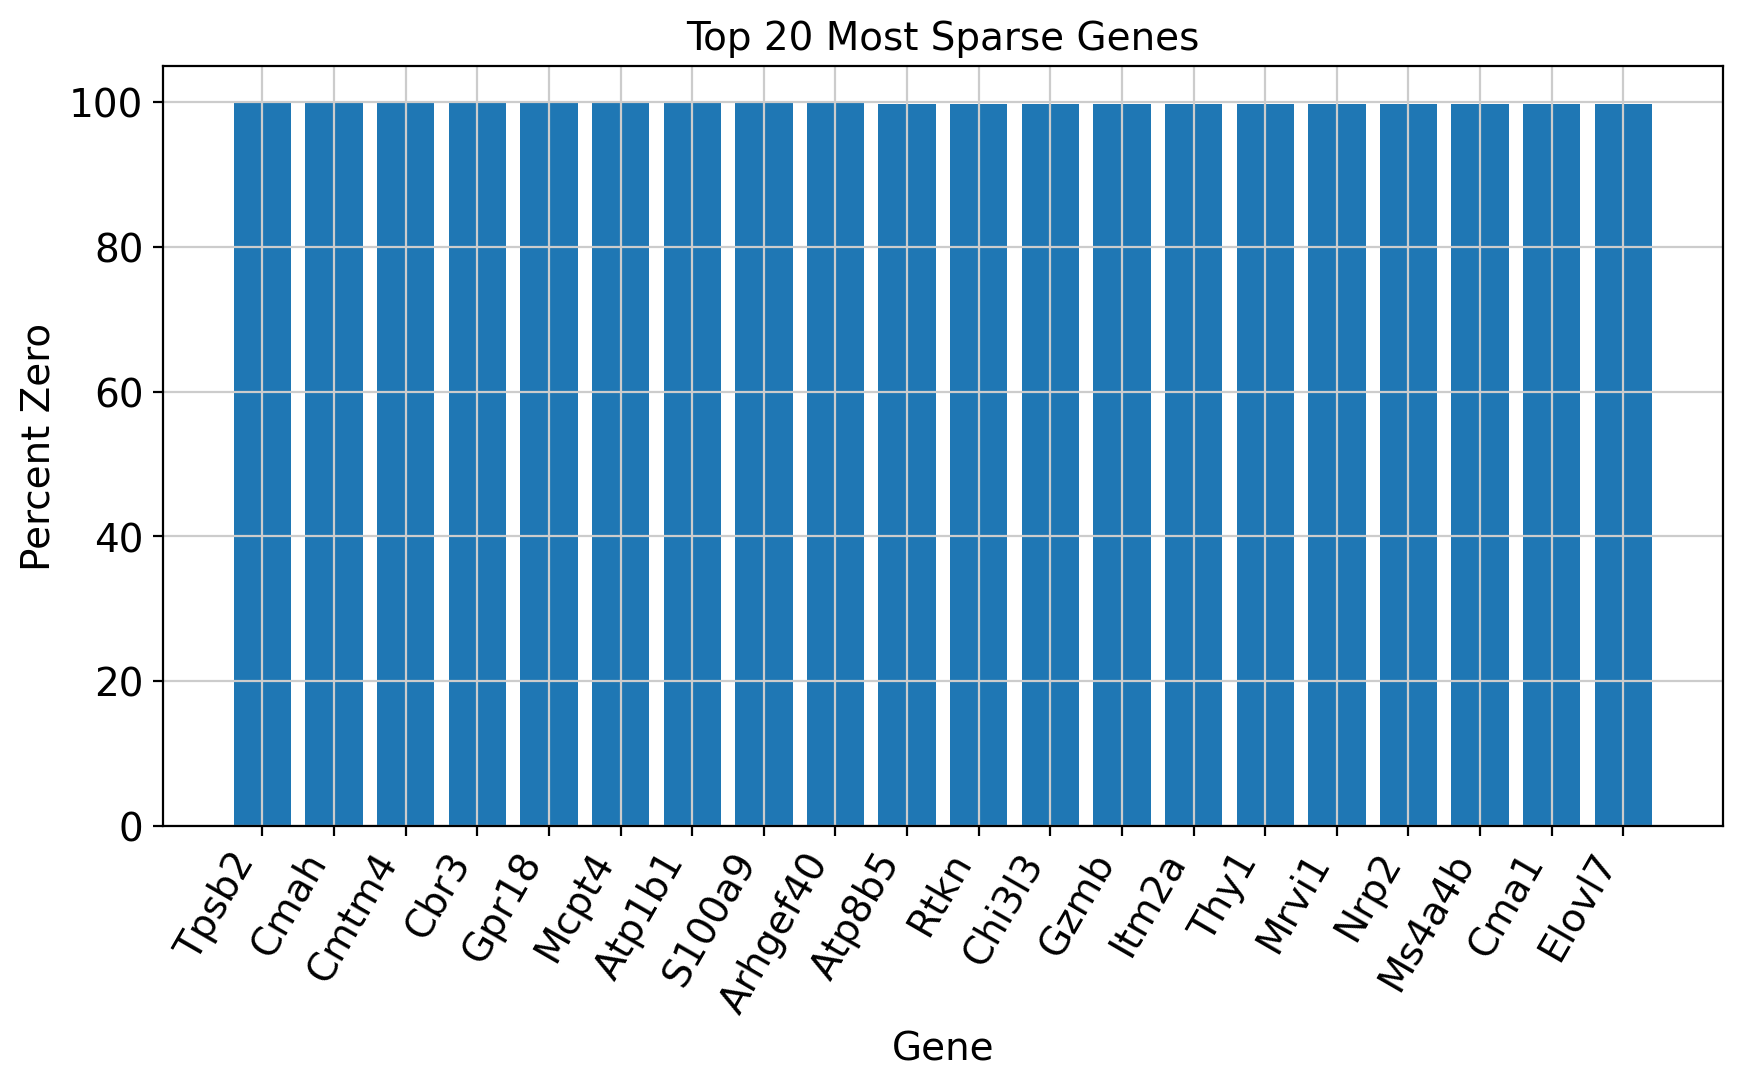

Figure saved to: ../student_inputs/genki/figure09_top20_sparse_genes.png


In [42]:
# Step 26. Plot top 20 most sparse genes

import matplotlib.pyplot as plt

top20_sparse = zero_table.head(20)

plt.figure(figsize=(10,5))

plt.bar(
    top20_sparse["Gene"],
    top20_sparse["Zero_percent"]
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Percent Zero")
plt.xlabel("Gene")
plt.title("Top 20 Most Sparse Genes")

figure_path = os.path.join(
    save_dir,
    "figure09_top20_sparse_genes.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [46]:
# Step 27. Calculate gene detection rate

import pandas as pd
import numpy as np

gene_detection_rate = (
    np.array((adata.X > 0).sum(axis=0)).flatten()
    / adata.n_obs
)

detection_table = pd.DataFrame({
    "Gene": adata.var_names,
    "Detection_rate": gene_detection_rate
})

detection_table = detection_table.sort_values(
    by="Detection_rate",
    ascending=False
)

print(detection_table.head(20))

          Gene  Detection_rate
1320    Gnb2l1        1.000000
196       Actb        0.998571
2640      Rps3        0.998571
2628      Rpl4        0.995714
1496  Hsp90ab1        0.992857
998       Eef2        0.990000
2622    Rpl13a        0.987143
1351      Gpx1        0.985714
1298   Gm10653        0.984286
2636     Rps20        0.980000
144   AK158095        0.975714
2025       Ncl        0.967143
1913       Mpo        0.960000
3250       Ubb        0.957143
2629     Rplp2        0.957143
393      Atp5b        0.952857
1213      Ftl1        0.950000
683       Cfl1        0.950000
2621     Rpl13        0.945714
2645      Rps8        0.944286


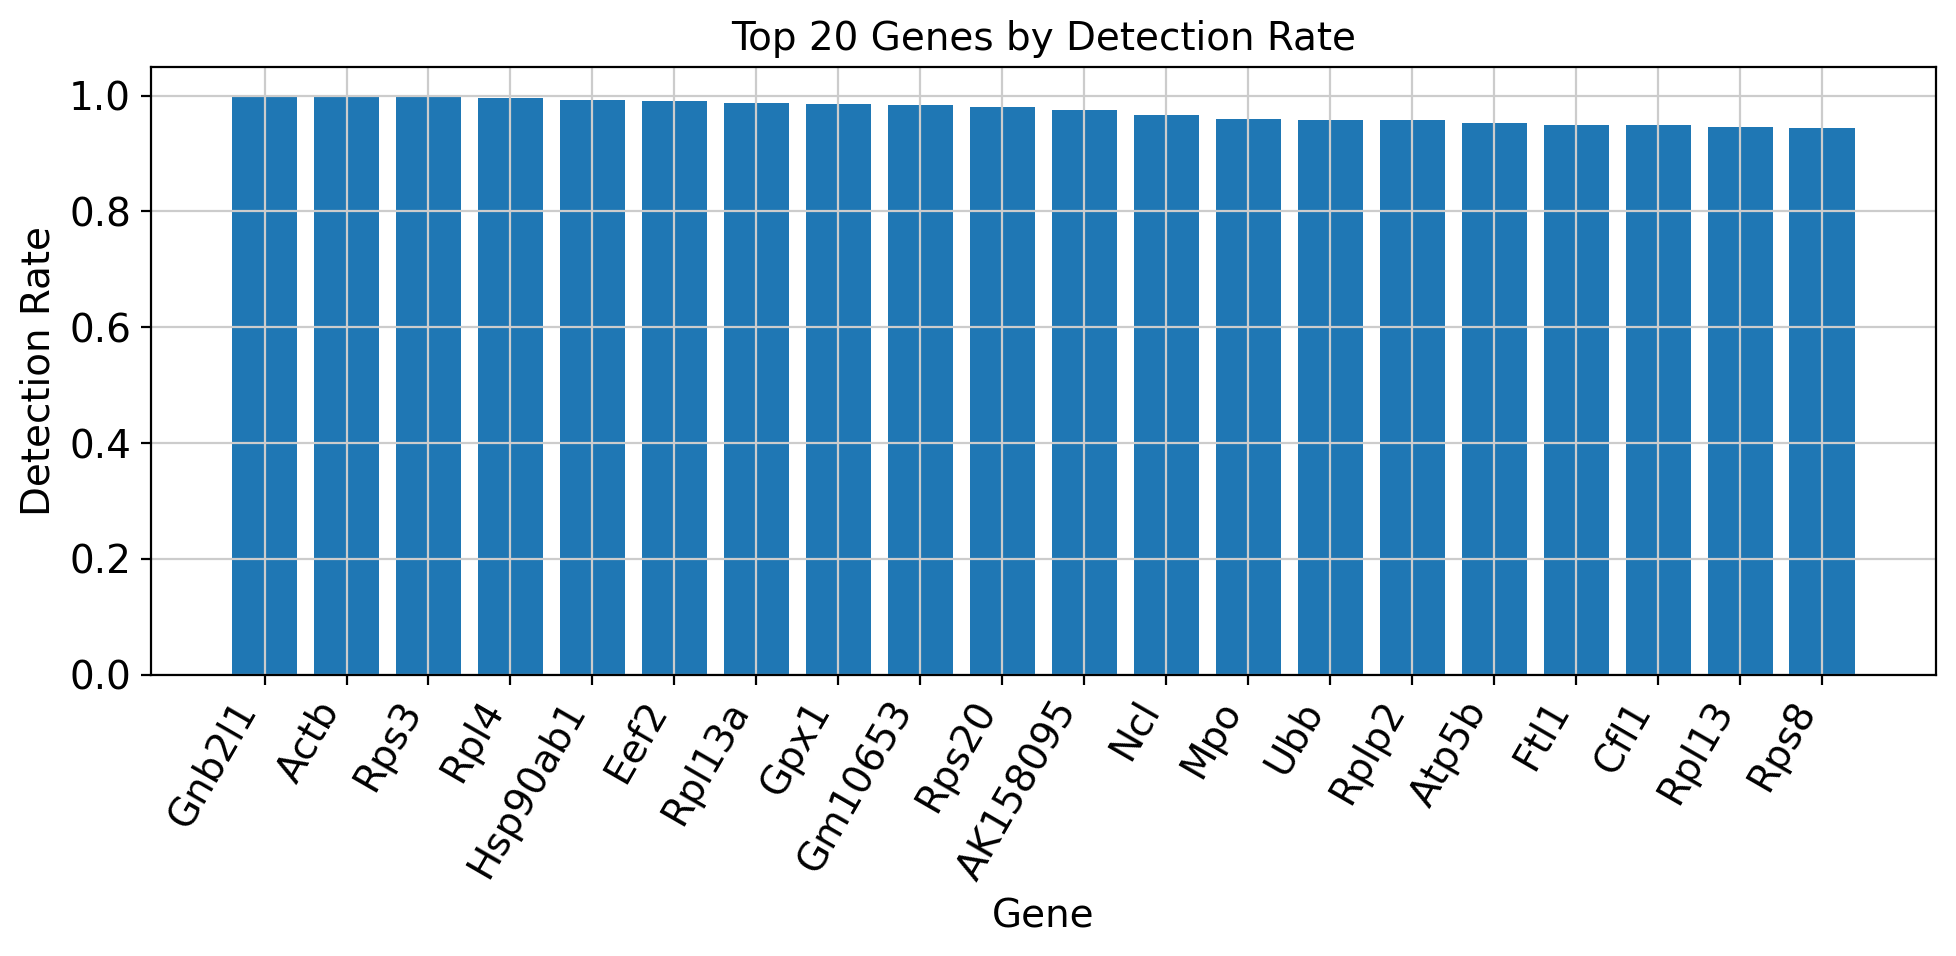

Figure saved to: ../student_inputs/genki/figure10_top20_detection_rate.png


In [47]:
# Step 28. Plot gene detection rate

import matplotlib.pyplot as plt
import os

top20_detected = detection_table.head(20)

plt.figure(figsize=(10,5))

plt.bar(
    top20_detected["Gene"],
    top20_detected["Detection_rate"]
)

plt.xticks(rotation=60, ha="right")
plt.xlabel("Gene")
plt.ylabel("Detection Rate")
plt.title("Top 20 Genes by Detection Rate")

plt.tight_layout()

figure_path = os.path.join(
    save_dir,
    "figure10_top20_detection_rate.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

In [48]:
# Step 29. Filter genes by detection rate

min_detection_rate = 0.05

selected_genes = detection_table[
    detection_table["Detection_rate"] >= min_detection_rate
]["Gene"].tolist()

print(f"Minimum detection rate: {min_detection_rate}")
print(f"Number of selected genes: {len(selected_genes)}")
print(f"Number of original genes: {adata.n_vars}")
print("First 20 selected genes:")
print(selected_genes[:20])

Minimum detection rate: 0.05
Number of selected genes: 2631
Number of original genes: 3451
First 20 selected genes:
['Gnb2l1', 'Actb', 'Rps3', 'Rpl4', 'Hsp90ab1', 'Eef2', 'Rpl13a', 'Gpx1', 'Gm10653', 'Rps20', 'AK158095', 'Ncl', 'Mpo', 'Ubb', 'Rplp2', 'Atp5b', 'Ftl1', 'Cfl1', 'Rpl13', 'Rps8']


In [49]:
# Step 30. Create filtered AnnData

adata_filtered = adata[:, selected_genes].copy()

print("Original shape:", adata.shape)
print("Filtered shape:", adata_filtered.shape)

Original shape: (700, 3451)
Filtered shape: (700, 2631)


In [50]:
# Step 31. Save filtered AnnData

import os

save_dir = "../student_inputs/genki"
os.makedirs(save_dir, exist_ok=True)

filtered_path = os.path.join(
    save_dir,
    "mouse_paul15_filtered_detection005.h5ad"
)

adata_filtered.write_h5ad(filtered_path)

print(f"Filtered AnnData saved to: {filtered_path}")
print(adata_filtered)

Filtered AnnData saved to: ../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad
AnnData object with n_obs × n_vars = 700 × 2631
    obs: 'paul15_clusters', 'cell_type'
    uns: 'iroot'


In [51]:
# Step 32. Check GenKI input files

import os

genki_input_dir = "../student_inputs/genki"

print("Files in GenKI input folder:")
for file in os.listdir(genki_input_dir):
    print(file)

Files in GenKI input folder:
figure04_top20_genes.png
figure06_top20_cells_expressing_genes.png
figure03_mean_expression_by_celltype.png
figure07_top20_percent_cells.png
mouse_paul15_filtered_detection005.h5ad
figure09_top20_sparse_genes.png
figure05_top20_variable_genes.png
figure02_gene_expression_histogram.png
figure01_cell_type_distribution.png
figure10_top20_detection_rate.png
figure08_bottom20_cells_expressing.png


In [52]:
# Step 33. Save selected gene list

selected_gene_path = "../student_inputs/genki/selected_genes_detection005.txt"

with open(selected_gene_path, "w") as f:
    for gene in selected_genes:
        f.write(gene + "\n")

print(f"Selected gene list saved to: {selected_gene_path}")
print(f"Number of selected genes: {len(selected_genes)}")

Selected gene list saved to: ../student_inputs/genki/selected_genes_detection005.txt
Number of selected genes: 2631


In [53]:
# Step 34. Final check of filtered AnnData

print("=" * 60)
print("Final GenKI input dataset")
print("=" * 60)

print(adata_filtered)

print("\nShape:")
print(f"Cells : {adata_filtered.n_obs}")
print(f"Genes : {adata_filtered.n_vars}")

print("\nObservation columns:")
print(list(adata_filtered.obs.columns))

print("\nFirst 10 genes:")
print(adata_filtered.var_names[:10].tolist())

Final GenKI input dataset
AnnData object with n_obs × n_vars = 700 × 2631
    obs: 'paul15_clusters', 'cell_type'
    uns: 'iroot'

Shape:
Cells : 700
Genes : 2631

Observation columns:
['paul15_clusters', 'cell_type']

First 10 genes:
['Gnb2l1', 'Actb', 'Rps3', 'Rpl4', 'Hsp90ab1', 'Eef2', 'Rpl13a', 'Gpx1', 'Gm10653', 'Rps20']


In [54]:
# Step 35. Set GenKI run configuration

USE_SAMPLE_DATA = False

MY_H5AD = "../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad"

TARGET_GENE = None

OBS_LABEL = "cell_type"

SAMPLE_H5AD = "genki_demo_wt.h5ad"

N_PCS = 150
N_PERMUTATIONS = 100
N_GENES = 100
N_CELLS = 85
CUTOFF = 0.996
SEED = 8096

print("GenKI configuration")
print("USE_SAMPLE_DATA:", USE_SAMPLE_DATA)
print("MY_H5AD:", MY_H5AD)
print("TARGET_GENE:", TARGET_GENE)
print("OBS_LABEL:", OBS_LABEL)
print("N_PCS:", N_PCS)
print("N_PERMUTATIONS:", N_PERMUTATIONS)
print("N_GENES:", N_GENES)
print("N_CELLS:", N_CELLS)
print("CUTOFF:", CUTOFF)
print("SEED:", SEED)

GenKI configuration
USE_SAMPLE_DATA: False
MY_H5AD: ../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad
TARGET_GENE: None
OBS_LABEL: cell_type
N_PCS: 150
N_PERMUTATIONS: 100
N_GENES: 100
N_CELLS: 85
CUTOFF: 0.996
SEED: 8096


In [55]:
# Step 36. Load the GenKI input dataset

import scanpy as sc

genki_adata = sc.read_h5ad(MY_H5AD)

print("Loaded GenKI input dataset:")
print(genki_adata)

print("\nShape:")
print(genki_adata.shape)

print("\nObservation columns:")
print(list(genki_adata.obs.columns))

print("\nUsing observation label:")
print(OBS_LABEL)

print("\nCell type counts:")
print(genki_adata.obs[OBS_LABEL].value_counts())

Loaded GenKI input dataset:
AnnData object with n_obs × n_vars = 700 × 2631
    obs: 'paul15_clusters', 'cell_type'
    uns: 'iroot'

Shape:
(700, 2631)

Observation columns:
['paul15_clusters', 'cell_type']

Using observation label:
cell_type

Cell type counts:
cell_type
14Mo       92
13Baso     83
2Ery       79
3Ery       71
15Mo       47
6Ery       45
5Ery       44
10GMP      43
7MEP       39
16Neu      39
4Ery       34
8Mk        19
1Ery       15
12Baso     15
9GMP       15
11DC        7
19Lymph     7
17Neu       5
18Eos       1
Name: count, dtype: int64


In [56]:
# Step 37. Verify selected gene list

with open("../student_inputs/genki/selected_genes_detection005.txt", "r") as f:
    gene_list = [line.strip() for line in f]

print(f"Genes in txt file : {len(gene_list)}")
print(f"Genes in AnnData  : {genki_adata.n_vars}")

print("\nFirst 20 genes:")
print(gene_list[:20])

print("\nGene list matches AnnData:",
      len(gene_list) == genki_adata.n_vars)

Genes in txt file : 2631
Genes in AnnData  : 2631

First 20 genes:
['Gnb2l1', 'Actb', 'Rps3', 'Rpl4', 'Hsp90ab1', 'Eef2', 'Rpl13a', 'Gpx1', 'Gm10653', 'Rps20', 'AK158095', 'Ncl', 'Mpo', 'Ubb', 'Rplp2', 'Atp5b', 'Ftl1', 'Cfl1', 'Rpl13', 'Rps8']

Gene list matches AnnData: True


In [57]:
# Step 38. Verify GenKI input consistency

print("=" * 60)
print("GenKI Input Consistency Check")
print("=" * 60)

print(f"H5AD file        : {MY_H5AD}")
print(f"Cells            : {genki_adata.n_obs}")
print(f"Genes            : {genki_adata.n_vars}")
print(f"Observation label: {OBS_LABEL}")

print("\nUnique cell types:")
print(genki_adata.obs[OBS_LABEL].unique())

print(f"\nNumber of cell types: {genki_adata.obs[OBS_LABEL].nunique()}")

print("\nDataset is ready for GenKI training.")

GenKI Input Consistency Check
H5AD file        : ../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad
Cells            : 700
Genes            : 2631
Observation label: cell_type

Unique cell types:
['3Ery', '14Mo', '7MEP', '9GMP', '16Neu', ..., '12Baso', '17Neu', '8Mk', '11DC', '18Eos']
Length: 19
Categories (19, object): ['1Ery', '2Ery', '3Ery', '4Ery', ..., '16Neu', '17Neu', '18Eos', '19Lymph']

Number of cell types: 19

Dataset is ready for GenKI training.


In [58]:
# Step 39. Create GenKI output folders

import os

OUTPUT_DIR = "../student_inputs/genki/genki_outputs"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

for folder in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    os.makedirs(folder, exist_ok=True)

print("GenKI output folders created:")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("MODEL_DIR:", MODEL_DIR)

GenKI output folders created:
OUTPUT_DIR: ../student_inputs/genki/genki_outputs
FIGURE_DIR: ../student_inputs/genki/genki_outputs/figures
TABLE_DIR: ../student_inputs/genki/genki_outputs/tables
MODEL_DIR: ../student_inputs/genki/genki_outputs/models


In [59]:
# Step 40. Save GenKI configuration as a JSON file

import json
import os

config = {
    "USE_SAMPLE_DATA": USE_SAMPLE_DATA,
    "MY_H5AD": MY_H5AD,
    "TARGET_GENE": TARGET_GENE,
    "OBS_LABEL": OBS_LABEL,
    "N_PCS": N_PCS,
    "N_PERMUTATIONS": N_PERMUTATIONS,
    "N_GENES": N_GENES,
    "N_CELLS": N_CELLS,
    "CUTOFF": CUTOFF,
    "SEED": SEED
}

config_path = os.path.join(OUTPUT_DIR, "genki_config.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("GenKI configuration saved to:")
print(config_path)
print(config)

GenKI configuration saved to:
../student_inputs/genki/genki_outputs/genki_config.json
{'USE_SAMPLE_DATA': False, 'MY_H5AD': '../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad', 'TARGET_GENE': None, 'OBS_LABEL': 'cell_type', 'N_PCS': 150, 'N_PERMUTATIONS': 100, 'N_GENES': 100, 'N_CELLS': 85, 'CUTOFF': 0.996, 'SEED': 8096}


In [60]:
# Step 41. Preview GenKI output directory structure

import os

print("=" * 60)
print("GenKI output directory")
print("=" * 60)

for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)

    for file in sorted(files):
        print(f"{subindent}{file}")

GenKI output directory
genki_outputs/
    genki_config.json
    models/
    tables/
    figures/


In [66]:
# Step 42. Verify GenKI installation

import GenKI

print("=" * 60)
print("GenKI installation check")
print("=" * 60)

print("Version:", GenKI.__version__)
print("Location:", GenKI.__file__)

GenKI installation check
Version: 0.2.1
Location: /usr/local/lib/python3.10/site-packages/GenKI/__init__.py


In [67]:
# Step 43. Check available GenKI functions

print("=" * 60)
print("Available GenKI functions")
print("=" * 60)

for item in sorted(dir(GenKI)):
    if not item.startswith("_"):
        print(item)

Available GenKI functions
DataLoader
GenKI
VGAE_trainer
api
build_adata
dataLoader
get_distance
get_generank
make_pcNet
model
pcNet
preprocessing
scBase
train
utils
version


In [68]:
# Step 44. Confirm training environment

print("=" * 60)
print("Training environment summary")
print("=" * 60)

print(f"Cells : {genki_adata.n_obs}")
print(f"Genes : {genki_adata.n_vars}")
print(f"Cell types : {genki_adata.obs[OBS_LABEL].nunique()}")

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nStatus:")
print("✓ GenKI imported")
print("✓ Dataset prepared")
print("✓ Output folders created")
print("✓ Ready for training")

Training environment summary
Cells : 700
Genes : 2631
Cell types : 19

Output directory:
../student_inputs/genki/genki_outputs

Status:
✓ GenKI imported
✓ Dataset prepared
✓ Output folders created
✓ Ready for training


In [71]:
# Step 45. Inspect real GenKI functions

import GenKI
import inspect

print("=" * 60)
print("Real GenKI public functions")
print("=" * 60)

for name in sorted(dir(GenKI)):
    if not name.startswith("_"):
        obj = getattr(GenKI, name)
        print("\n" + "-" * 60)
        print(name)
        print(type(obj))
        
        try:
            print(inspect.signature(obj))
        except Exception as e:
            print("No signature available")

Real GenKI public functions

------------------------------------------------------------
DataLoader
<class 'type'>
(adata: anndata._core.anndata.AnnData, target_gene: list[str], target_cell: str = None, obs_label: str = 'ident', GRN_file_dir: str = 'GRNs', rebuild_GRN: bool = True, cutoff: int = 85, **kwargs)

------------------------------------------------------------
GenKI
<class 'type'>
(adata, target_gene, *, target_cell=None, obs_label: 'str' = 'ident', cutoff: 'int' = 85, grn_dir: 'str' = 'GRNs', rebuild_grn: 'bool' = True, **grn_kwargs)

------------------------------------------------------------
VGAE_trainer
<class 'type'>
(data, out_channels: int = 2, epochs: int = 100, lr: float = 0.0007, weight_decay=0.0009, beta: float = 0.0001, log_dir: str = None, verbose: bool = True, seed: int = None, **kwargs)

------------------------------------------------------------
api
<class 'module'>
No signature available

------------------------------------------------------------
build_a

In [72]:
# Step 46. Build GenKI AnnData object

print("=" * 60)
print("Build GenKI AnnData object")
print("=" * 60)

genki_built_adata = GenKI.build_adata(
    adata=genki_adata,
    sep="\t",
    log_normalize=False,
    scale_data=False,
    uppercases=False
)

print("GenKI AnnData object created successfully.")
print(genki_built_adata)
print("\nObservation columns:")
print(list(genki_built_adata.obs.columns))
print("\nVariable columns:")
print(list(genki_built_adata.var.columns))

Build GenKI AnnData object
GenKI AnnData object created successfully.
AnnData object with n_obs × n_vars = 700 × 2631
    obs: 'paul15_clusters', 'cell_type'
    uns: 'iroot'

Observation columns:
['paul15_clusters', 'cell_type']

Variable columns:
[]


In [74]:
# Step 47. Add normalized layer for GenKI

import scanpy as sc

print("=" * 60)
print("Add normalized layer for GenKI")
print("=" * 60)

genki_ready_adata = genki_built_adata.copy()

# Normalize total counts per cell
sc.pp.normalize_total(genki_ready_adata, target_sum=1e4)

# Save normalized counts to the layer required by GenKI
genki_ready_adata.layers["norm"] = genki_ready_adata.X.copy()

# Log-transform and scale adata.X for GenKI
sc.pp.log1p(genki_ready_adata)
sc.pp.scale(genki_ready_adata)

print("GenKI-ready AnnData created.")
print(genki_ready_adata)

print("\nLayers:")
print(list(genki_ready_adata.layers.keys()))

print("\nReady for scBase initialization.")

Add normalized layer for GenKI
GenKI-ready AnnData created.
AnnData object with n_obs × n_vars = 700 × 2631
    obs: 'paul15_clusters', 'cell_type'
    var: 'mean', 'std'
    uns: 'iroot', 'log1p'
    layers: 'norm'

Layers:
['norm']

Ready for scBase initialization.


/usr/local/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [76]:
# Step 48. Convert GenKI-ready matrix to sparse format

from scipy import sparse

print("=" * 60)
print("Convert adata.X to sparse matrix")
print("=" * 60)

genki_ready_adata.X = sparse.csr_matrix(genki_ready_adata.X)

print("adata.X type:")
print(type(genki_ready_adata.X))

print("\nLayers:")
print(list(genki_ready_adata.layers.keys()))

print("\nReady to initialize scBase again.")

Convert adata.X to sparse matrix
adata.X type:
<class 'scipy.sparse._csr.csr_matrix'>

Layers:
['norm']

Ready to initialize scBase again.


In [78]:
# Step 49. Initialize GenKI scBase object again

print("=" * 60)
print("Initialize GenKI scBase object again")
print("=" * 60)

target_gene = genki_ready_adata.var_names[:N_GENES].tolist()

genki_model = GenKI.scBase(
    adata=genki_ready_adata,
    target_gene=target_gene,
    target_cell=None,
    obs_label=OBS_LABEL,
    GRN_file_dir="GRNs",
    rebuild_GRN=True,
)

print("GenKI scBase object initialized successfully.")
print(type(genki_model))

print("\nNumber of target genes:")
print(len(target_gene))

print("\nFirst 10 target genes:")
print(target_gene[:10])

Initialize GenKI scBase object again
GenKI scBase object initialized successfully.
<class 'GenKI.dataLoader.scBase'>

Number of target genes:
100

First 10 target genes:
['GNB2L1', 'ACTB', 'RPS3', 'RPL4', 'HSP90AB1', 'EEF2', 'RPL13A', 'GPX1', 'GM10653', 'RPS20']


In [79]:
# Step 50. Inspect GenKI model object

print("=" * 60)
print("Inspect GenKI scBase object")
print("=" * 60)

print("Object type:")
print(type(genki_model))

print("\nAvailable attributes:")
for item in sorted(dir(genki_model)):
    if not item.startswith("_"):
        print(item)

Inspect GenKI scBase object
Object type:
<class 'GenKI.dataLoader.scBase'>

Available attributes:
counts
net
target_gene


In [80]:
# Step 51. Inspect VGAE trainer interface

import inspect

print("=" * 60)
print("Inspect VGAE trainer")
print("=" * 60)

print("VGAE_trainer signature:")
print(inspect.signature(GenKI.VGAE_trainer))

print("\nVGAE_trainer public attributes:")
for item in sorted(dir(GenKI.VGAE_trainer)):
    if not item.startswith("_"):
        print(item)

Inspect VGAE trainer
VGAE_trainer signature:
(data, out_channels: int = 2, epochs: int = 100, lr: float = 0.0007, weight_decay=0.0009, beta: float = 0.0001, log_dir: str = None, verbose: bool = True, seed: int = None, **kwargs)

VGAE_trainer public attributes:
get_latent_vars
load_model
pmt
save_model
train


In [84]:
# Step 52. Inspect scBase internal objects safely

print("=" * 60)
print("Inspect scBase internal objects safely")
print("=" * 60)

for name in ["counts", "net", "target_gene"]:
    obj = getattr(genki_model, name)

    print("\n" + "-" * 60)
    print(name)
    print("type:", type(obj))

    if hasattr(obj, "shape"):
        print("shape:", obj.shape)

    if name == "target_gene":
        print("length:", len(obj))
        print("first 10:", obj[:10])

    if name == "net":
        print("net attributes:")
        for item in sorted(dir(obj)):
            if not item.startswith("_"):
                print(item)

Inspect scBase internal objects safely

------------------------------------------------------------
counts
type: <class 'scipy.sparse._lil.lil_matrix'>
shape: (700, 2631)

------------------------------------------------------------
net
type: <class 'scipy.sparse._csc.csc_matrix'>
shape: (2631, 2631)
net attributes:
A
H
T
arcsin
arcsinh
arctan
arctanh
argmax
argmin
asformat
asfptype
astype
ceil
check_format
conj
conjugate
copy
count_nonzero
data
deg2rad
diagonal
dot
dtype
eliminate_zeros
expm1
floor
format
getH
get_shape
getcol
getformat
getmaxprint
getnnz
getrow
has_canonical_format
has_sorted_indices
imag
indices
indptr
log1p
max
maximum
maxprint
mean
min
minimum
multiply
nanmax
nanmin
ndim
nnz
nonzero
power
prune
rad2deg
real
reshape
resize
rint
set_shape
setdiag
shape
sign
sin
sinh
size
sort_indices
sorted_indices
sqrt
sum
sum_duplicates
tan
tanh
toarray
tobsr
tocoo
tocsc
tocsr
todense
todia
todok
tolil
trace
transpose
trunc

-------------------------------------------------------

In [85]:
# Step 53. Add missing num_features attribute

print("=" * 60)
print("Add missing num_features attribute")
print("=" * 60)

genki_model.num_features = genki_model.counts.shape[1]

print("num_features:")
print(genki_model.num_features)

Add missing num_features attribute
num_features:
2631


In [86]:
# Step 54. Create VGAE trainer

print("=" * 60)
print("Create VGAE trainer")
print("=" * 60)

trainer = GenKI.VGAE_trainer(
    data=genki_model,
    out_channels=2,
    epochs=100,
    lr=0.0007,
    weight_decay=0.0009,
    beta=0.0001,
    verbose=True
)

print("\nTrainer created successfully!")
print(type(trainer))

Create VGAE trainer

Trainer created successfully!
<class 'GenKI.train.VGAE_trainer'>


In [95]:
# Step 55. Build sparse PyTorch Geometric gene graph data

import torch
from torch_geometric.data import Data
import numpy as np

print("=" * 60)
print("Build sparse PyTorch Geometric gene graph data")
print("=" * 60)

TOP_EDGES = 20000

x_array = genki_model.counts.T.toarray()
x = torch.tensor(x_array, dtype=torch.float)

net_coo = genki_model.net.tocoo()

# remove self-loops
mask = net_coo.row != net_coo.col
rows = net_coo.row[mask]
cols = net_coo.col[mask]
vals = net_coo.data[mask]

# keep top weighted edges
top_idx = np.argsort(np.abs(vals))[-TOP_EDGES:]

edge_index = torch.tensor(
    np.array([rows[top_idx], cols[top_idx]]),
    dtype=torch.long
)

genki_graph_data = Data(
    x=x,
    edge_index=edge_index
)

print(genki_graph_data)
print("num_features:", genki_graph_data.num_features)
print("num_nodes:", genki_graph_data.num_nodes)
print("num_edges:", genki_graph_data.num_edges)
print("max edge index:", int(edge_index.max()))

Build sparse PyTorch Geometric gene graph data
Data(x=[2631, 700], edge_index=[2, 20000])
num_features: 700
num_nodes: 2631
num_edges: 20000
max edge index: 2607


In [96]:
# Step 56. Create VGAE trainer with graph data

print("=" * 60)
print("Create VGAE trainer with graph data")
print("=" * 60)

trainer = GenKI.VGAE_trainer(
    data=genki_graph_data,
    out_channels=2,
    epochs=100,
    lr=0.0007,
    weight_decay=0.0009,
    beta=0.0001,
    verbose=True
)

print("Trainer created successfully.")
print(type(trainer))

Create VGAE trainer with graph data
Trainer created successfully.
<class 'GenKI.train.VGAE_trainer'>


In [97]:
# Step 57. Train the VGAE model

print("=" * 60)
print("Train VGAE model")
print("=" * 60)

trainer.train()

print("\nTraining finished.")

Train VGAE model

Training finished.


In [100]:
# Step 58. Save trained VGAE model

import os
import torch

print("=" * 60)
print("Save trained VGAE model")
print("=" * 60)

MODEL_DIR = "../student_inputs/genki/genki_outputs/models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "vgae_model_state_dict.pt")

torch.save(trainer.model.state_dict(), model_path)

print("Model saved to:")
print(model_path)

Save trained VGAE model
Model saved to:
../student_inputs/genki/genki_outputs/models/vgae_model_state_dict.pt


In [102]:
# Step 59. Extract latent representation

print("=" * 60)
print("Extract latent representation")
print("=" * 60)

latent = trainer.get_latent_vars(genki_graph_data)

print("Latent representation extracted.")
print("type:", type(latent))

try:
    print("shape:", latent.shape)
except:
    print("No shape attribute.")

print(latent[:5])

Extract latent representation
Latent representation extracted.
type: <class 'tuple'>
No shape attribute.
(array([[-0.29477885, -2.1325748 ],
       [-0.6723199 , -3.3173318 ],
       [-0.33735454, -2.2482667 ],
       ...,
       [-0.09024429, -1.2782959 ],
       [ 0.0447278 ,  0.06455972],
       [-0.18019949, -0.3997456 ]], dtype=float32), array([[0.37838727, 0.18369266],
       [0.35526034, 0.03788558],
       [0.40384534, 0.14158593],
       ...,
       [0.3698687 , 0.5178817 ],
       [0.910515  , 0.8782928 ],
       [1.1094788 , 0.50768304]], dtype=float32))


In [103]:
# Step 60. Inspect latent variables

print("=" * 60)
print("Inspect latent variables")
print("=" * 60)

print("Tuple length:", len(latent))

for i, item in enumerate(latent):
    print(f"\nItem {i}")
    print("type:", type(item))

    try:
        print("shape:", item.shape)
    except:
        pass

    print(item[:5])

Inspect latent variables
Tuple length: 2

Item 0
type: <class 'numpy.ndarray'>
shape: (2631, 2)
[[-0.29477885 -2.1325748 ]
 [-0.6723199  -3.3173318 ]
 [-0.33735454 -2.2482667 ]
 [-0.30418622 -2.280528  ]
 [-0.3489262  -3.5806828 ]]

Item 1
type: <class 'numpy.ndarray'>
shape: (2631, 2)
[[0.37838727 0.18369266]
 [0.35526034 0.03788558]
 [0.40384534 0.14158593]
 [0.32857215 0.17981438]
 [0.10147586 0.14574558]]


In [104]:
# Step 61. Save latent representation

import numpy as np
import os

print("=" * 60)
print("Save latent representation")
print("=" * 60)

latent_dir = "../student_inputs/genki/genki_outputs/tables"
os.makedirs(latent_dir, exist_ok=True)

np.save(os.path.join(latent_dir, "latent_mu.npy"), latent[0])
np.save(os.path.join(latent_dir, "latent_logstd.npy"), latent[1])

print("Latent variables saved successfully.")

Save latent representation
Latent variables saved successfully.


In [109]:
# Step 62. Configure advanced GenKI run

print("=" * 60)
print("Configure advanced GenKI run")
print("=" * 60)

USE_SAMPLE_DATA = False

MY_H5AD = "../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad"
OBS_LABEL = "cell_type"
TARGET_GENE = "Gnb2l1"

SAMPLE_DATA = "genki_demo_wt.h5ad"

EPOCHS = 30
N_PERMUTATIONS = 0
CUTOFF = 85
N_TOP = 15
SEED = 8096

print("USE_SAMPLE_DATA:", USE_SAMPLE_DATA)
print("MY_H5AD:", MY_H5AD)
print("OBS_LABEL:", OBS_LABEL)
print("TARGET_GENE:", TARGET_GENE)
print("EPOCHS:", EPOCHS)
print("N_PERMUTATIONS:", N_PERMUTATIONS)
print("CUTOFF:", CUTOFF)
print("N_TOP:", N_TOP)
print("SEED:", SEED)

Configure advanced GenKI run
USE_SAMPLE_DATA: False
MY_H5AD: ../student_inputs/genki/mouse_paul15_filtered_detection005.h5ad
OBS_LABEL: cell_type
TARGET_GENE: Gnb2l1
EPOCHS: 30
N_PERMUTATIONS: 0
CUTOFF: 85
N_TOP: 15
SEED: 8096


In [106]:
# Step 63. Import required packages

import os
import io
import sys
import time
import logging
import contextlib
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

import GenKI

warnings.filterwarnings("ignore")

print("=" * 60)
print("Packages imported successfully.")
print("=" * 60)

Packages imported successfully.


In [107]:
# Step 64. Load h5ad dataset

print("=" * 60)
print("Load h5ad dataset")
print("=" * 60)

adata = sc.read_h5ad(MY_H5AD)

print("Dataset loaded successfully.")
print(adata)

print("\nNumber of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

print("\nobs columns:")
print(list(adata.obs.columns))

print("\nFirst five genes:")
print(adata.var_names[:5])

Load h5ad dataset
Dataset loaded successfully.
AnnData object with n_obs × n_vars = 700 × 2631
    obs: 'paul15_clusters', 'cell_type'
    uns: 'iroot'

Number of cells: 700
Number of genes: 2631

obs columns:
['paul15_clusters', 'cell_type']

First five genes:
Index(['Gnb2l1', 'Actb', 'Rps3', 'Rpl4', 'Hsp90ab1'], dtype='object')


In [110]:
# Step 65. Check target gene

print("=" * 60)
print("Check target gene")
print("=" * 60)

print("Target gene:", TARGET_GENE)

if TARGET_GENE in adata.var_names:
    print("✓ Target gene found.")
    gene_idx = adata.var_names.get_loc(TARGET_GENE)
    print("Gene index:", gene_idx)

    expr = adata[:, TARGET_GENE].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray()

    print("Expression shape:", expr.shape)
    print("Expression range:",
          float(expr.min()),
          "~",
          float(expr.max()))
else:
    raise ValueError(f"{TARGET_GENE} not found!")

Check target gene
Target gene: Gnb2l1
✓ Target gene found.
Gene index: 0
Expression shape: (700, 1)
Expression range: 1.0 ~ 88.0


In [111]:
# Step 66. Check cell labels

print("=" * 60)
print("Check cell labels")
print("=" * 60)

print("OBS_LABEL:", OBS_LABEL)

if OBS_LABEL not in adata.obs.columns:
    raise ValueError(f"{OBS_LABEL} not found in adata.obs!")

labels = adata.obs[OBS_LABEL]

print("\nNumber of cells:", len(labels))
print("Number of cell types:", labels.nunique())

print("\nCell type counts:")
print(labels.value_counts())

print("\nFirst 10 labels:")
print(labels.head(10))

Check cell labels
OBS_LABEL: cell_type

Number of cells: 700
Number of cell types: 19

Cell type counts:
cell_type
14Mo       92
13Baso     83
2Ery       79
3Ery       71
15Mo       47
6Ery       45
5Ery       44
10GMP      43
7MEP       39
16Neu      39
4Ery       34
8Mk        19
1Ery       15
12Baso     15
9GMP       15
11DC        7
19Lymph     7
17Neu       5
18Eos       1
Name: count, dtype: int64

First 10 labels:
W31109     3Ery
W31118     14Mo
W31121     7MEP
W31126     3Ery
W31127     9GMP
W31131    16Neu
W31136     3Ery
W31137     2Ery
W31138     3Ery
W31140     3Ery
Name: cell_type, dtype: category
Categories (19, object): ['1Ery', '2Ery', '3Ery', '4Ery', ..., '16Neu', '17Neu', '18Eos', '19Lymph']


In [113]:
print("=" * 60)
print("Save normalized counts to adata.layers['norm']")
print("=" * 60)

adata.layers["norm"] = adata.X.copy()

print("Done!")
print(adata.layers.keys())

Save normalized counts to adata.layers['norm']
Done!
KeysView(Layers with keys: norm)


In [115]:
import scanpy as sc

print("=" * 60)
print("Standardize adata.X")
print("=" * 60)

# 从 normalized counts 开始
adata.X = adata.layers["norm"].copy()

# z-score
sc.pp.scale(adata)

print("Done.")
print("X range:",
      float(adata.X.min()),
      float(adata.X.max()))

Standardize adata.X
Done.
X range: -1.6589734766523434 22.658029404517


In [117]:
# Step 66.7 Convert standardized X to sparse matrix

from scipy import sparse

print("=" * 60)
print("Convert standardized adata.X to sparse matrix")
print("=" * 60)

adata.X = sparse.csr_matrix(adata.X)

print("Done.")
print("adata.X type:")
print(type(adata.X))
print("adata.X shape:")
print(adata.X.shape)

Convert standardized adata.X to sparse matrix
Done.
adata.X type:
<class 'scipy.sparse._csr.csr_matrix'>
adata.X shape:
(700, 2631)


In [120]:
# Step 67. Create GenKI analysis object

print("=" * 60)
print("Create GenKI analysis object")
print("=" * 60)

genki_model = GenKI.GenKI(
    adata=adata,
    target_gene=[TARGET_GENE],
    obs_label=OBS_LABEL
)

print("GenKI analysis object created successfully.")
print(type(genki_model))

Create GenKI analysis object
GenKI analysis object created successfully.
<class 'GenKI.api.GenKI'>


In [121]:
# Step 68. Inspect GenKI object

print("=" * 60)
print("Inspect GenKI object")
print("=" * 60)

print("Object type:")
print(type(genki_model))

print("\nAvailable attributes:")
for item in sorted(dir(genki_model)):
    if not item.startswith("_"):
        print(item)

Inspect GenKI object
Object type:
<class 'GenKI.api.GenKI'>

Available attributes:
fit
from_adata
from_h5ad
ko_data
loader
metrics
predict
run
target_gene
trainer
wt_data


In [122]:
# Step 69. Check run() documentation

print("=" * 60)
print("Check run()")
print("=" * 60)

help(genki_model.run)

Check run()
Help on method run in module GenKI.api:

run(*, epochs: 'int' = 100, lr: 'float' = 0.0007, weight_decay: 'float' = 0.0009, beta: 'float' = 0.0001, out_channels: 'int' = 2, seed: 'int | None' = None, log_dir: 'str | None' = None, verbose: 'bool' = False, n_permutations: 'int' = 100, by: 'str' = 'KL', generank_kwargs: 'dict | None' = None, **train_kwargs) method of GenKI.api.GenKI instance
    Convenience: ``fit`` then ``predict`` in a single call.



In [125]:
# ============================================================
# Step 70. Check GenKI API
# ============================================================

import inspect

print("=" * 60)
print("GenKI version")
print("=" * 60)

import GenKI
print(GenKI.__version__)

print("\nrun()")
print(inspect.signature(genki_model.run))

print("\nfit()")
print(inspect.signature(genki_model.fit))

print("\npredict()")
print(inspect.signature(genki_model.predict))

GenKI version
0.2.1

run()
(*, epochs: 'int' = 100, lr: 'float' = 0.0007, weight_decay: 'float' = 0.0009, beta: 'float' = 0.0001, out_channels: 'int' = 2, seed: 'int | None' = None, log_dir: 'str | None' = None, verbose: 'bool' = False, n_permutations: 'int' = 100, by: 'str' = 'KL', generank_kwargs: 'dict | None' = None, **train_kwargs)

fit()
(*, epochs: 'int' = 100, lr: 'float' = 0.0007, weight_decay: 'float' = 0.0009, beta: 'float' = 0.0001, out_channels: 'int' = 2, seed: 'int | None' = None, log_dir: 'str | None' = None, verbose: 'bool' = False, **train_kwargs) -> "'GenKI'"

predict()
(*, n_permutations: 'int' = 100, by: 'str' = 'KL', **generank_kwargs)


In [126]:
# ============================================================
# Step 71. Check GenKI installation path
# ============================================================

print("=" * 60)
print("Check GenKI installation path")
print("=" * 60)

import GenKI

print(GenKI.__file__)

Check GenKI installation path
/usr/local/lib/python3.10/site-packages/GenKI/__init__.py


In [127]:
# ============================================================
# Step 72. Check pip version
# ============================================================

print("=" * 60)
print("Check pip version")
print("=" * 60)

import pip

print(pip.__version__)

Check pip version
23.0.1


In [128]:
# ============================================================
# Step 73. Check Python version
# ============================================================

print("=" * 60)
print("Check Python version")
print("=" * 60)

import sys

print(sys.version)

Check Python version
3.10.20 (main, May 19 2026, 23:57:38) [GCC 14.2.0]


In [131]:
# ============================================================
# Step 74. Check GenKI source location
# ============================================================

import os
import GenKI

print("=" * 60)
print("Check GenKI source location")
print("=" * 60)

print("GenKI version:")
print(GenKI.__version__)

print("\nGenKI file:")
print(GenKI.__file__)

print("\nGenKI folder:")
print(os.path.dirname(GenKI.__file__))

Check GenKI source location
GenKI version:
0.2.1

GenKI file:
/usr/local/lib/python3.10/site-packages/GenKI/__init__.py

GenKI folder:
/usr/local/lib/python3.10/site-packages/GenKI


In [132]:
# ============================================================
# Step 75. Inspect split_data()
# ============================================================

import inspect
from GenKI.train import split_data

print("=" * 60)
print("split_data signature")
print("=" * 60)

print(inspect.signature(split_data))

split_data signature
(dir: str = 'data', data=None, load: bool = False, save: bool = False)


In [133]:
# ============================================================
# Step 76. Fit GenKI model
# ============================================================

print("=" * 60)
print("Fit GenKI model")
print("=" * 60)

genki_model.fit(
    epochs=EPOCHS,
    seed=SEED
)

print("GenKI model fitted successfully.")

Fit GenKI model
GenKI model fitted successfully.


In [134]:
# ============================================================
# Step 77. Predict GenKI result
# ============================================================

print("=" * 60)
print("Predict GenKI result")
print("=" * 60)

result = genki_model.predict(
    n_permutations=N_PERMUTATIONS,
    by="KL"
)

print("Prediction finished.")
print(type(result))
print(result)

Predict GenKI result
Prediction finished.
<class 'pandas.core.frame.DataFrame'>
                 dis  rank
Gnb2l1  1.161144e+01     1
Prkd2   3.701497e-04     2
Rps3    1.979325e-04     3
H2afy   1.938122e-04     4
Actb    1.837090e-04     5
...              ...   ...
Taf1    7.658660e-10  2627
Adk     5.822829e-10  2628
Hipk1   5.196525e-10  2629
Cdk6    2.233114e-10  2630
Crebbp  1.838796e-10  2631

[2631 rows x 2 columns]


In [145]:
# ==========================================================
# Step 79. Open prediction table
# ==========================================================

import pandas as pd

result = pd.read_csv("genki_outputs/tables/genki_prediction.csv")

result.head(20)

,Unnamed: 0,dis,rank
0,Gnb2l1,11.611440,1
1,Prkd2,0.000370,2
2,Rps3,0.000198,3
3,H2afy,0.000194,4
4,Actb,0.000184,5
5,Car1,0.000171,6
6,Car2,0.000169,7
7,Mpo,0.000166,8
8,Gpx1,0.000161,9
9,Elane,0.000154,10


In [ ]:
# ==========================================================
# Step 80. Rename columns
# ==========================================================

result = result.rename(columns={"Unnamed: 0": "Gene"})

result.head(20)